In [1]:
import torch
import numpy as np

from dataclasses import dataclass, field

from env.wrapper import EnvWrapper
from RL.ppo.ThrBLpolicy import PolicyNetwork
from RL.ppo.train_BLpolicy import PPOConfig#, model_summary

from game.enums import BoardType, Tribes

#%load_ext autoreload
#%autoreload 2

C:\Users\laure\0envs\pytorch_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
a

NameError: name 'a' is not defined

In [3]:
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#checkpoint = torch.load(r'./RL/ppo/checkpoints_new/policy_update_00079.pt', weights_only=True, map_location=device)



In [ ]:
@dataclass
class PPOConfig:

    # --- Parallelism ---
    n_processes:         int   = 8
    n_envs_per_process:  int   = 4

    # --- Environment ---
    # board_size is chosen randomly per episode; only type and player count
    # are fixed here.
    board_config_dict = {
        "board_type" : BoardType.Dummy,
        "n_players"  : 2,
    }
    player_tribes      = [Tribes.Omaji, Tribes.Imperius]
    max_turns_per_game = 100

    # --- Board size curriculum: uniform random square in [min, max] ──────────
    board_size_range:    tuple = (10, 16)

    # --- Rollout ---
    n_steps:             int   = 128

    # --- PPO epochs & batching ---
    n_epochs:            int   = 6
    n_minibatches:       int   = 4

    # --- PPO loss coefficients ---
    clip_eps:            float = 0.2
    vf_coef:             float = 0.5
    ent_coef:            float = 0.01
    max_grad_norm:       float = 0.5

    # --- GAE / discount ---
    gamma:               float = 0.99
    gae_lambda:          float = 0.95

    # --- Optimizer ---
    lr:                  float = 3e-4

    # --- Training ---
    n_updates:           int   = 20
    log_interval:        int   = 1

    # ── Model architecture ────────────────────────────────────────────────────
    mpnn_hidden_dim:     int   = 128    # GraphSAGE hidden size
    mlp_hidden_dim:      int   = 64   # MLP hidden layer width
    mlp_depth:           int   = 3     # number of hidden layers in every MLP

    @property
    def n_envs_total(self):
        return self.n_processes * self.n_envs_per_process

    @property
    def batch_size(self):
        return self.n_steps * self.n_envs_total

    @property
    def minibatch_size(self):
        return self.batch_size // self.n_minibatches

In [ ]:
cfg = PPOConfig()
#policy = PolicyNetwork(cfg).to(device)
#policy.load_state_dict(checkpoint)
#policy.eval()
#model_summary(policy)

In [4]:
board_config_dict = {
        "board_type" : BoardType.Dummy,
        "n_players"  : 2,
        "board_size" : (10,10)
    }

In [ ]:
def calc_probs_global_action_head(policy, obs, mask):
    N_tiles    = np.asarray(obs['partial_graph']).shape[0]
    Nx = Ny    = int(round(N_tiles ** 0.5))

    node_emb   = policy._encode(obs['partial_graph'], Nx, Ny)  # (N, node_dim)
    global_emb = node_emb.mean(dim=0, keepdim=True)
    #n_u, n_e, n_c = self._sizes(mask)

    logits = policy.action_type_head(global_emb).squeeze(0)
    print("logits: ", logits)
    return policy._dist(logits, mask[0]).probs
    

In [ ]:
env = EnvWrapper(board_config_dict, cfg.player_tribes,
                 max_turns_per_game=cfg.max_turns_per_game,
                 dense_reward=True)
obs  = env.reset()
done = False
step = 0

for i in range(100):
    mask             = env.get_action_mask()
    #print("-"*40,"Step {} mask".format(i),"-"*40,"\n",mask, "\n")
    
    with torch.no_grad():
        action, _, _, value = policy(obs, mask)

    #print("value:", value)
    #print(calc_probs_global_action_head(policy, obs, mask))
    translated_action = env._translate_action(action)
    obs, reward, done, info = env.step(action)

    
    #print(f"step {step:3d} | action: {info['log'].get('action_type')} | reward: {reward:.2f}")
    #env.render(shared_fog=True, critic_value=value, translated_action=translated_action)
    #for unit in env.game.players[env.game.player_go_id].units_under_control:
        #tile_id = unit.tile.id
        #print(unit)
        #print(env.game.players[env.game.player_go_id].partial_graph[tile_id])
    step += 1

    if done:
        print("We have a winner!")
        break

    
winner = env.winner
print(f"\nGame over — winner: {'Player ' + str(winner) if winner is not None else 'Draw (turn limit)'}")

In [ ]:
mask             = env.get_action_mask()
mask

In [ ]:
mask[2][0,1] =1
mask[0][1] = 1

# Running new model from here

In [ ]:
from RL.models.movement_module import MovementTargetHead, MovementUnitSelHead
from RL.models.main_modules import GraphTransformerEncoder
from RL.models.attack_module import AttackTargetHead, AttackUnitSelHead

In [ ]:
global_embedding = GraphTransformerEncoder()

In [ ]:
mvnt_lowest_head = MovementTargetHead(node_dim=128, n_heads=1)

In [ ]:
mvnt_middle_head = MovementUnitSelHead(node_dim=128, n_heads=1)

In [ ]:
atk_head_lowest = AttackTargetHead(n_heads=1)
atk_middle_head = AttackUnitSelHead(n_heads=1)

In [ ]:
embgs, _ = global_embedding.encode(obs["partial_graph"], 10, 10)

In [ ]:
result = mvnt_lowest_head.forward(embgs,
                         movement_mask=mask[1],
                         obs_units=obs["units"],
                         Nx=10, Ny=10)
print(result)

In [ ]:
mvnt_middle_head.forward(embgs,
                         target_result=result,
                         Ny=10)

## Attacking


In [ ]:
mask[2][0,-1]=1

In [ ]:
mask

In [ ]:
atk_result = atk_head_lowest.forward(embgs,
                                     mask[2],
                                     obs["units"],
                                     obs["enemy_units"],
                                     Ny=10)

atk_result

In [ ]:
atk_middle_head.forward(embgs, atk_result, Ny=10)

# The full new policy

In [5]:
from RL.models.policy import PolicyNetwork, model_summary

In [6]:
@dataclass
class PolicyConfig:
    """
    Full hyperparameter config for PolicyNetwork and its training environment.

    Encoder
    ───────
    encoder_hidden_dim : hidden width of GraphTransformerEncoder; must be
                         divisible by encoder_n_heads AND by 4 (RoPE requirement
                         for all selection heads that share this dimension).
    encoder_n_heads    : attention heads per TransformerConv layer.
    encoder_depth      : number of TransformerConv layers  (receptive field knob).

    Selection heads  (SequenceSelectionHead — shared by all four action lines)
    ───────────────
    sel_n_heads  : MHSA heads per transformer block.
    sel_n_layers : number of transformer blocks per head  (depth knob).

    MLP  (used by every _mlp() call across all heads)
    ───
    mlp_hidden_dim : hidden width.
    mlp_depth      : number of hidden layers (minimum 1).

    Multi-scale convolutions  (MovementTargetHead + CreateUnitTypeHead)
    ────────────────────────
    kernel_sizes  : spatial pooling scales, all odd ints, largest first.
    n_conv_layers : stacked Conv2d layers per kernel size
                    (expands receptive field without growing output width).

    Movement context window
    ───────────────────────
    context_bias : added to per-unit radius = int(mvpts*2 + attack_range) + bias.
                   Must be >= max(kernel_sizes) // 2.
    """

    board_config_dict = {
        "board_type" : BoardType.Dummy,
        "n_players"  : 2,
    }
    player_tribes      = [Tribes.Omaji, Tribes.Imperius]
    max_turns_per_game = 100
    # ── Encoder ────────────────────────────────────────────────────────────
    encoder_hidden_dim: int   = 64
    encoder_n_heads:    int   = 4
    encoder_depth:      int   = 4

    # ── Selection heads ────────────────────────────────────────────────────
    sel_n_heads:  int = 4
    sel_n_layers: int = 2

    # ── MLP ────────────────────────────────────────────────────────────────
    mlp_hidden_dim: int = 128
    mlp_depth:      int = 3

    # ── Multi-scale convolutions ───────────────────────────────────────────
    kernel_sizes:  Tuple[int, ...] = (5, 3)
    n_conv_layers: int             = 1

    # ── Movement context window ────────────────────────────────────────────
    context_bias: int = 4

    # ── Derived / validation ───────────────────────────────────────────────
    def __post_init__(self) -> None:
        assert self.encoder_hidden_dim % self.encoder_n_heads == 0, (
            f"encoder_hidden_dim ({self.encoder_hidden_dim}) must be divisible "
            f"by encoder_n_heads ({self.encoder_n_heads})."
        )
        assert self.encoder_hidden_dim % 4 == 0, (
            f"encoder_hidden_dim ({self.encoder_hidden_dim}) must be divisible "
            f"by 4 for 2D RoPE in selection heads."
        )
        assert all(k % 2 == 1 for k in self.kernel_sizes), \
            "All kernel_sizes must be odd integers."
        assert self.context_bias >= max(self.kernel_sizes) // 2, (
            f"context_bias ({self.context_bias}) must be >= "
            f"max(kernel_sizes)//2 ({max(self.kernel_sizes)//2})."
        )
        assert self.mlp_depth >= 1, "mlp_depth must be >= 1."
        assert self.n_conv_layers >= 1, "n_conv_layers must be >= 1."

In [7]:
cfg = PolicyConfig()

In [8]:
policy = PolicyNetwork(cfg) # go with default values
model_summary(policy)

  Module                                   Params
------------------------------------------------------------
  GraphTransformerEncoder                  69,568
  CriticHead                               41,729
  Action type head                         42,245
  MovementTargetHead                      230,977
  Move unit selector                      112,897
  AttackTargetHead                         75,201
  Attack unit selector                    112,897
  CreateUnitTypeHead                      197,634
  Create city selector                    112,897
  Capture selector                        108,673
  TOTAL                                 1,104,718
  TRAINABLE                             1,104,718


In [9]:
checkpoint = torch.load(r'./RL/ppo/checkpoints_hierarchical/policy_update_00022.pt', weights_only=True, map_location=device)

In [10]:
policy.load_state_dict(checkpoint)
policy.eval()

PolicyNetwork(
  (encoder): GraphTransformerEncoder(
    (input_proj): Linear(in_features=26, out_features=64, bias=True)
    (tf_layers): ModuleList(
      (0-3): 4 x TransformerConv(64, 16, heads=4)
    )
    (norms): ModuleList(
      (0-3): 4 x LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (critic): CriticHead(
    (value_mlp): Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=128, bias=True)
      (5): ReLU()
      (6): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (7): Linear(in_features=128, out_features=1, bias=True)
    )
  )
  (action_type_head): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
  

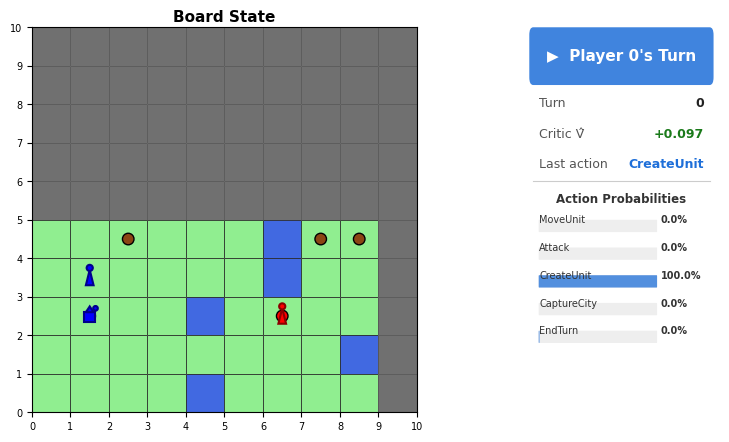

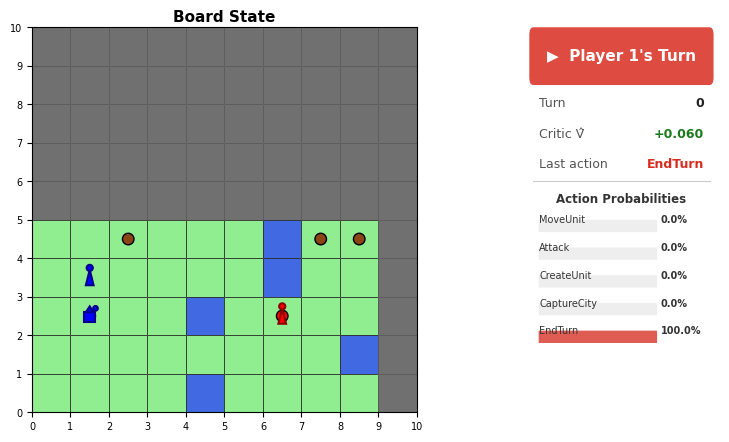

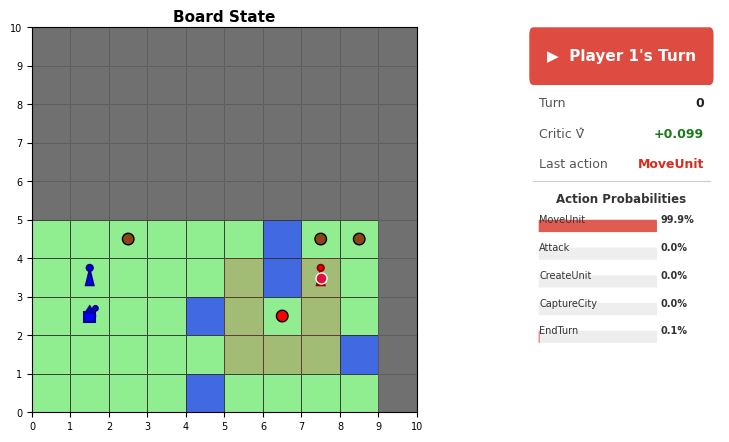

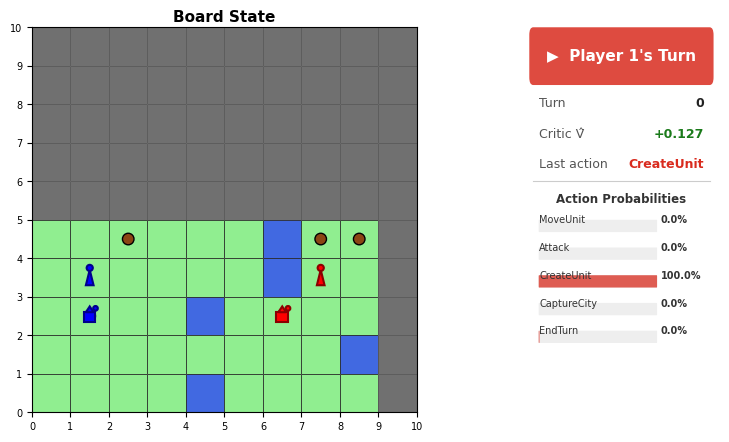

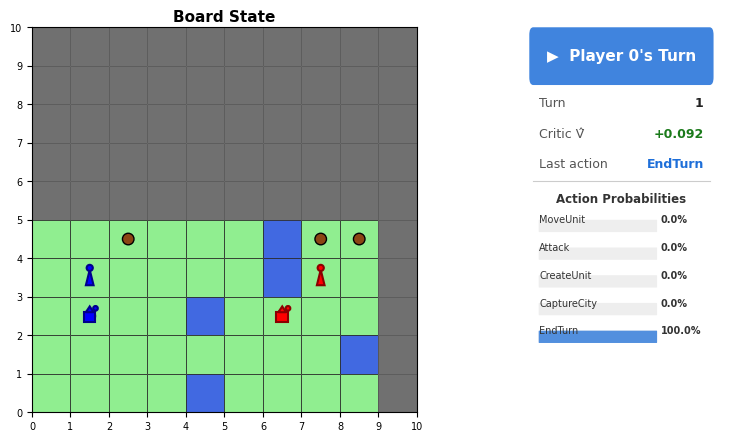

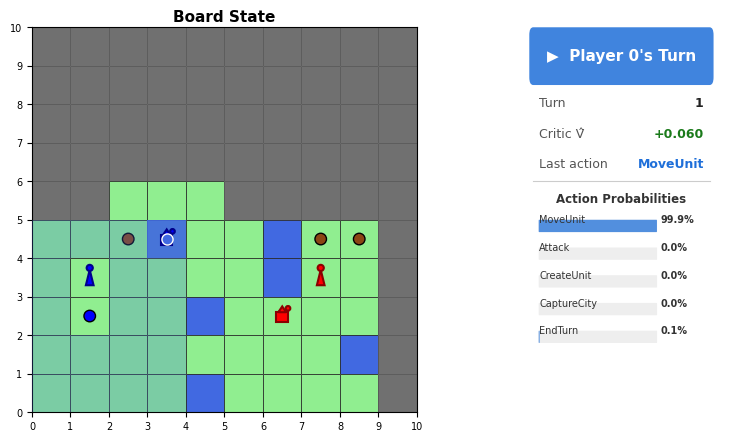

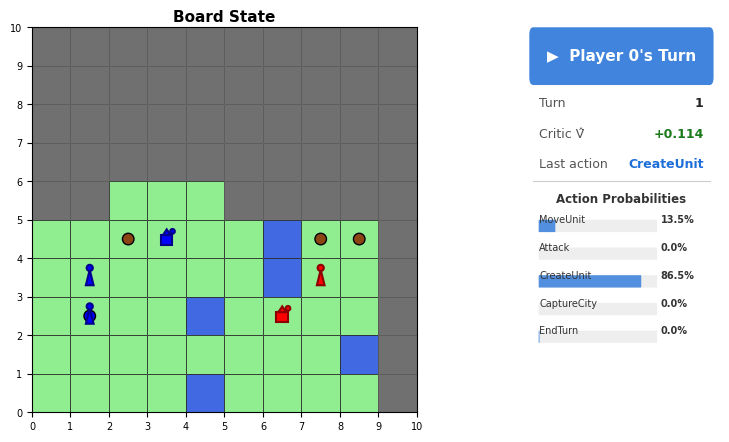

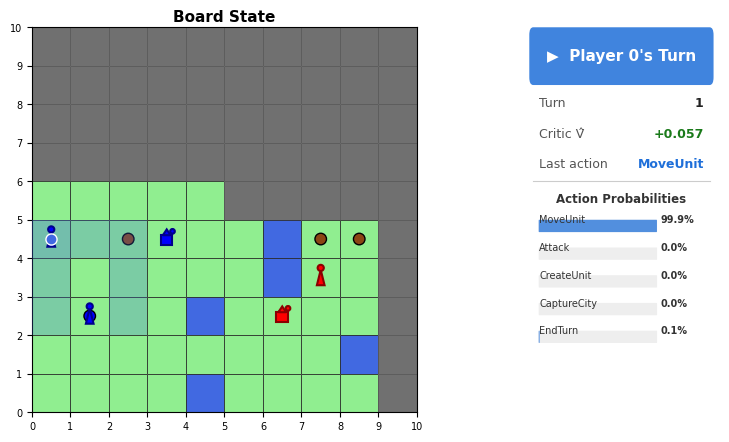

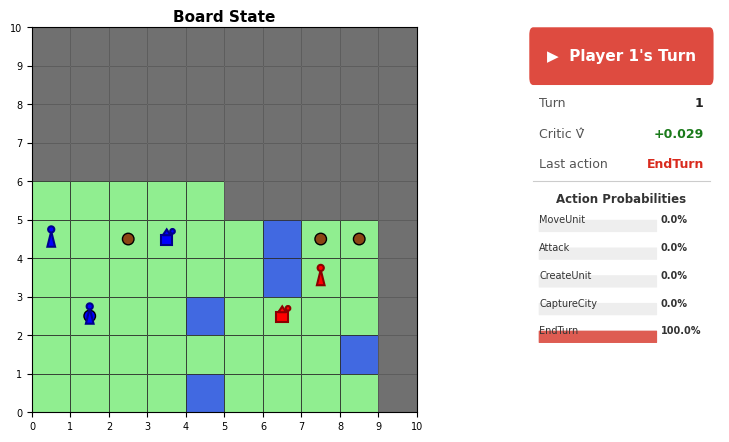

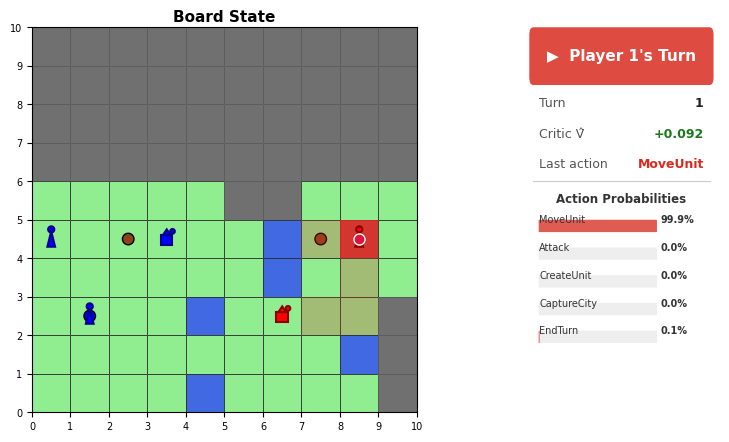

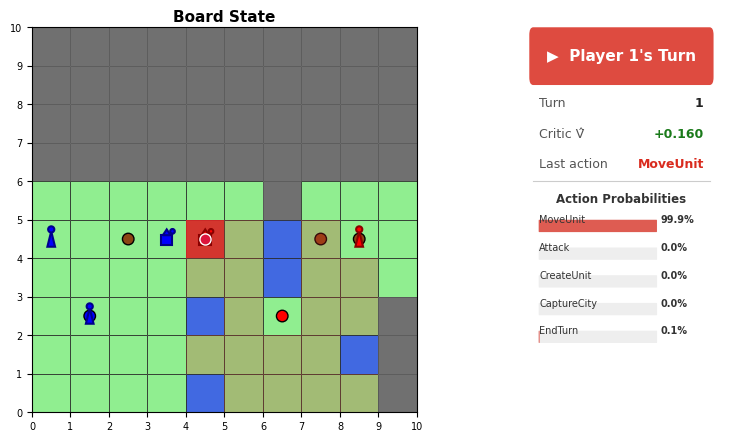

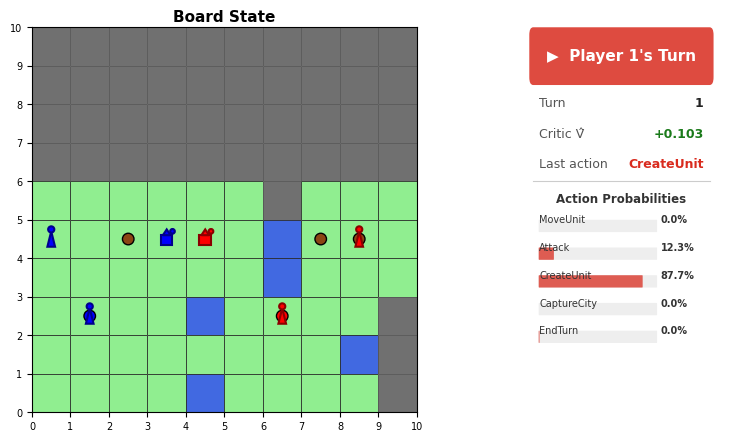

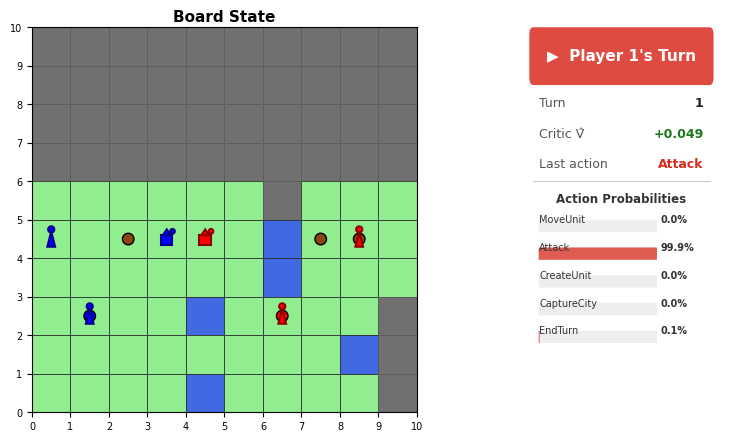

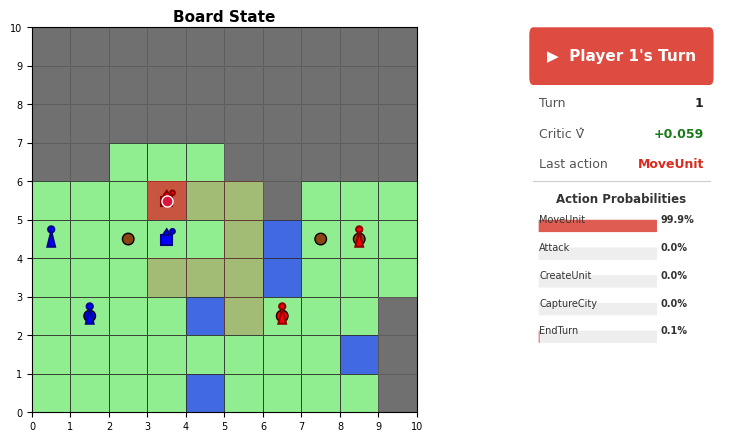

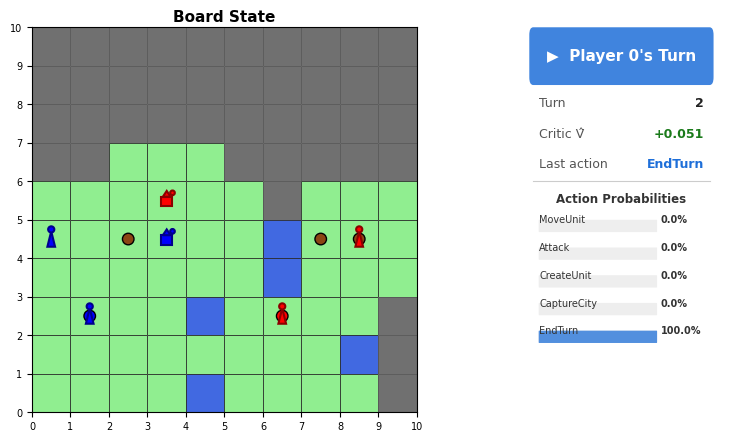

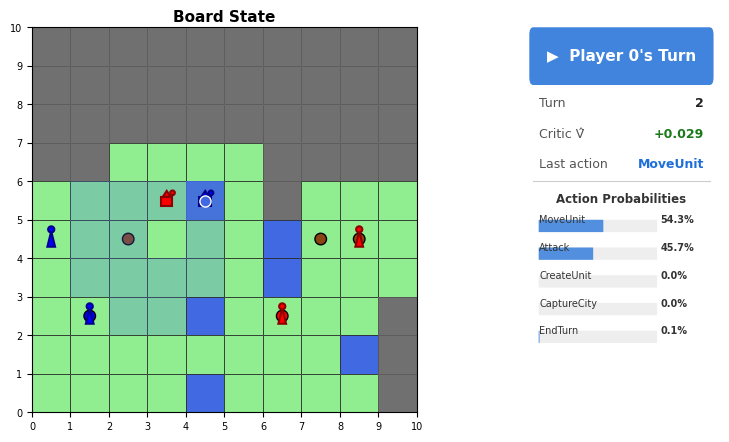

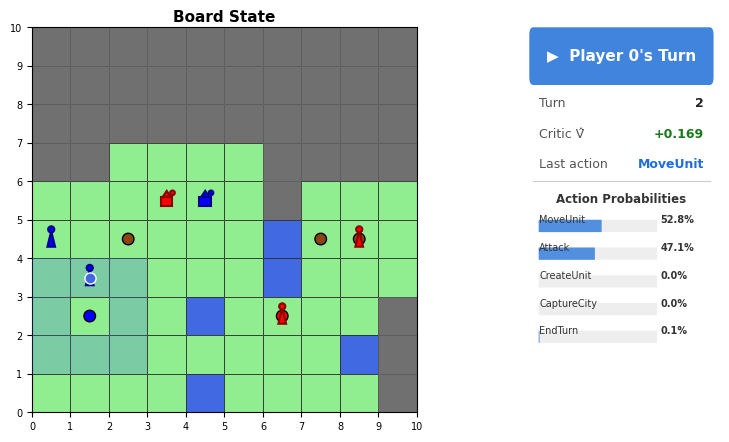

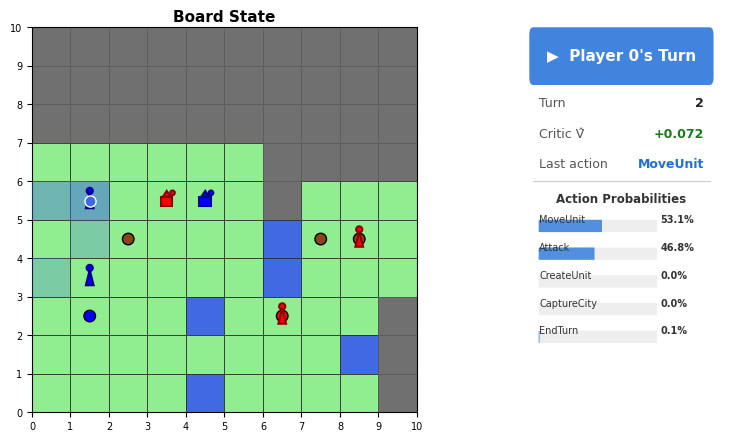

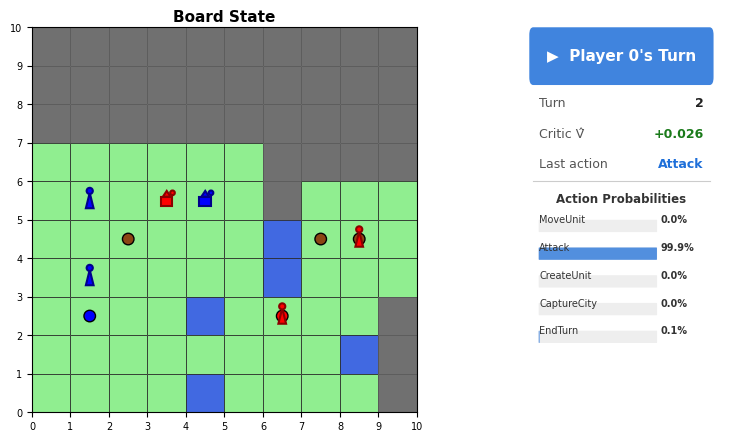

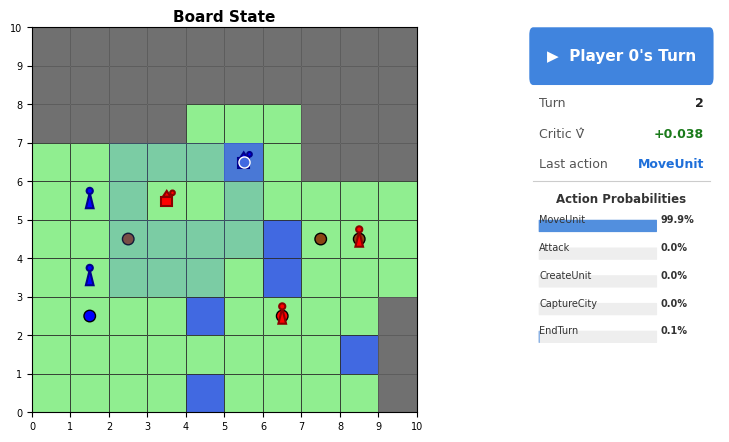

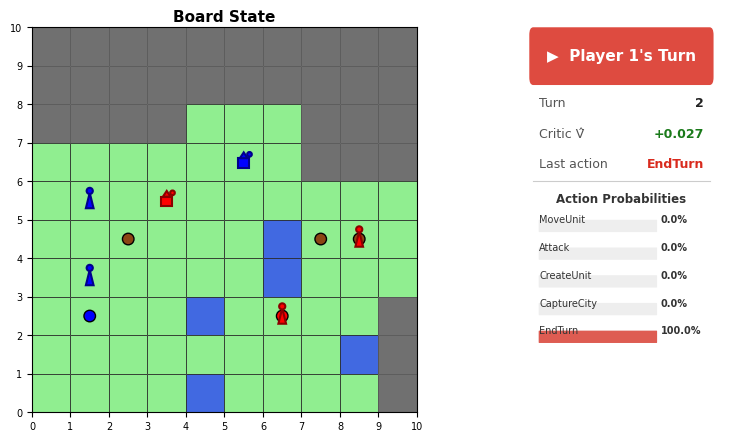

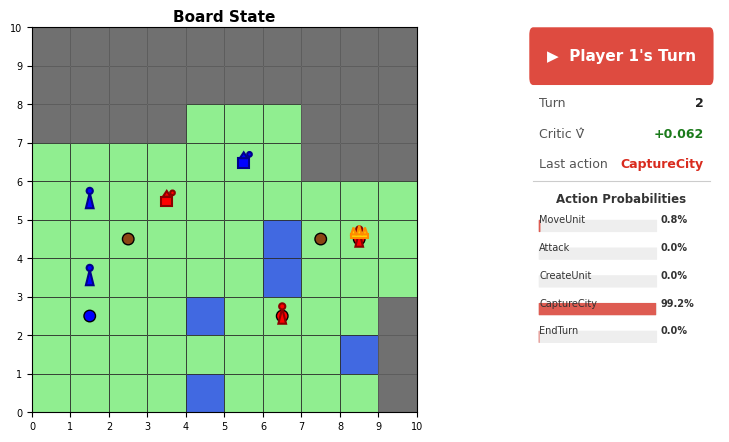

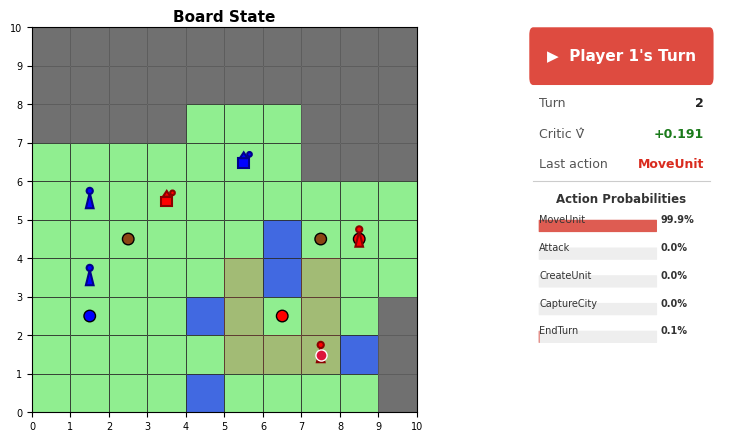

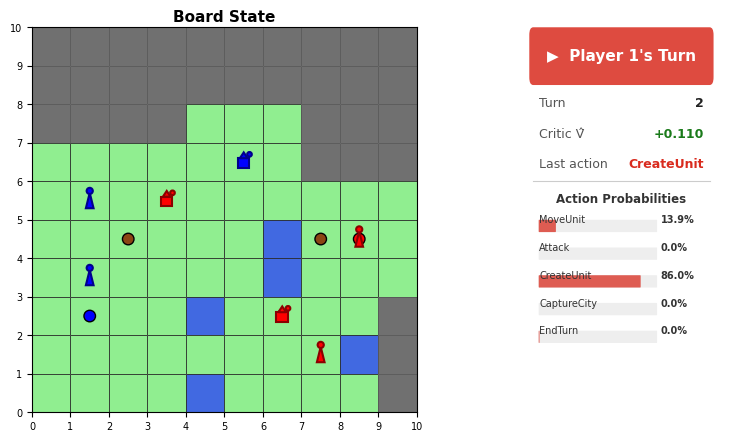

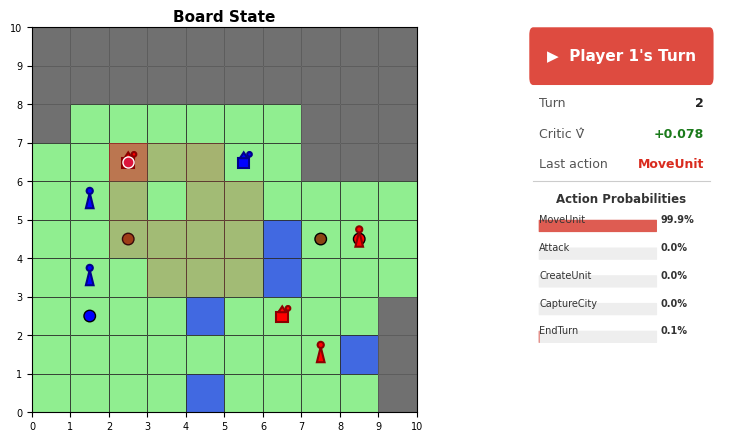

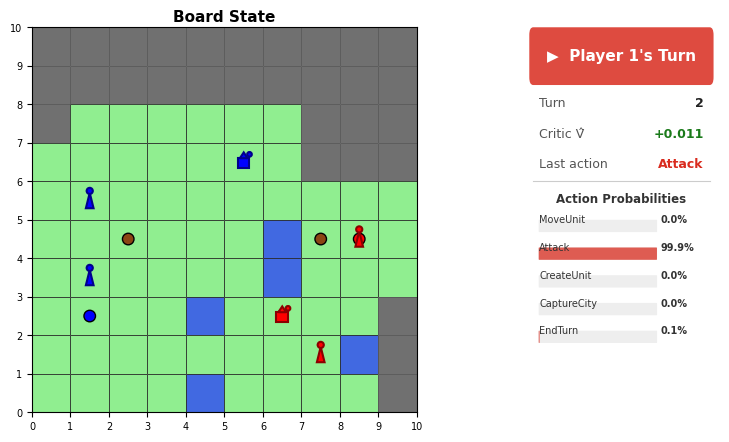

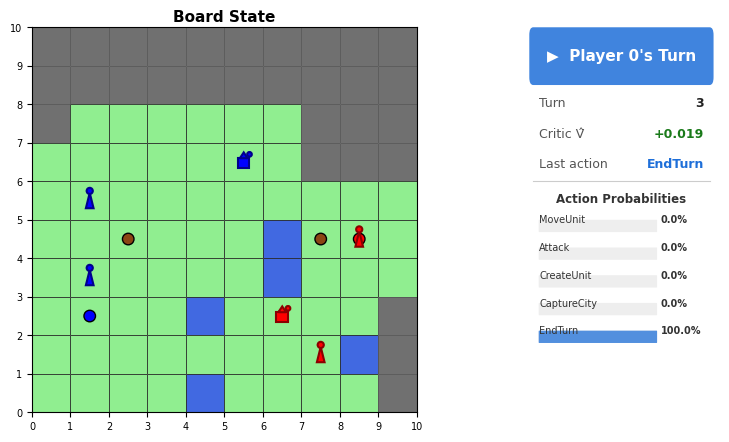

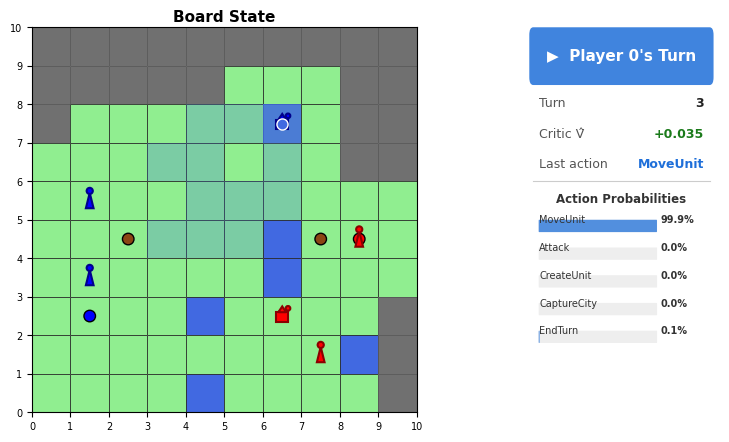

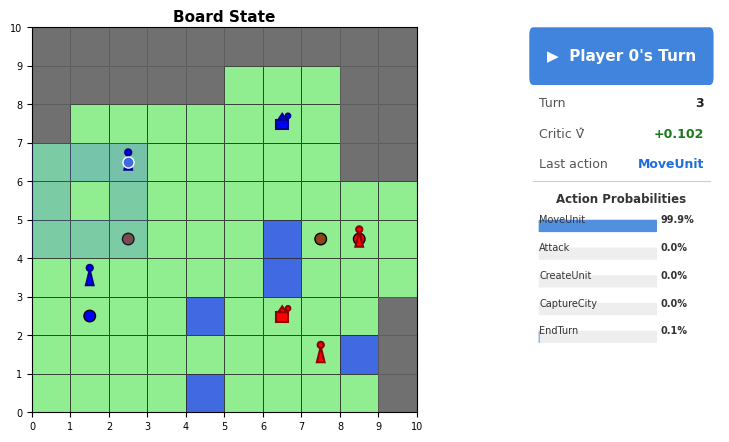

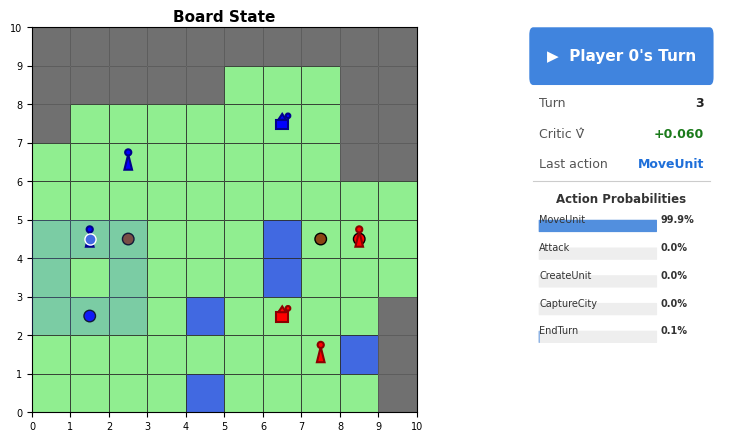

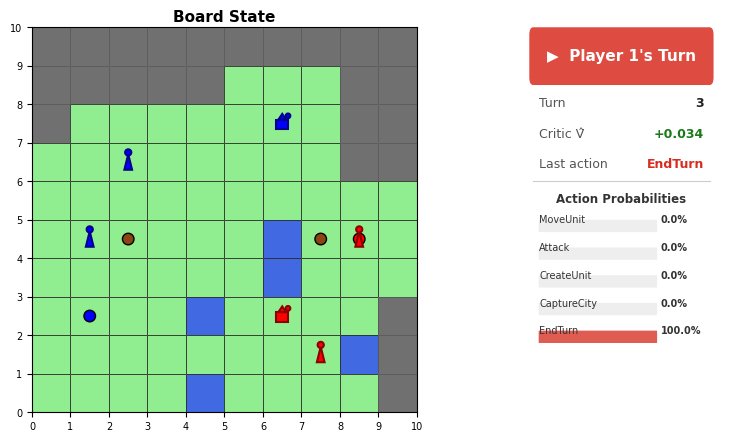

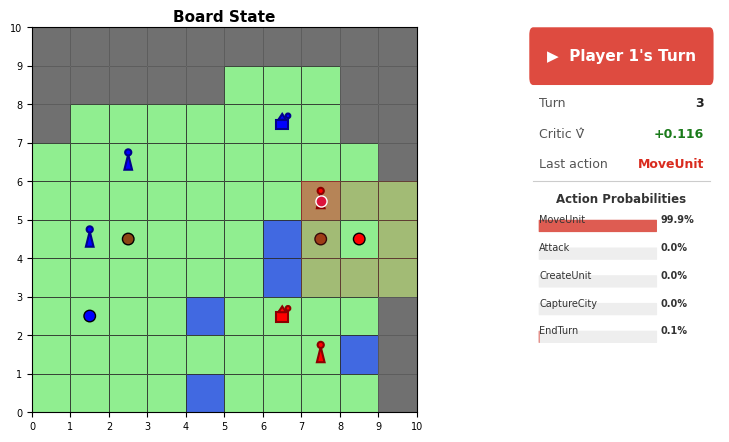

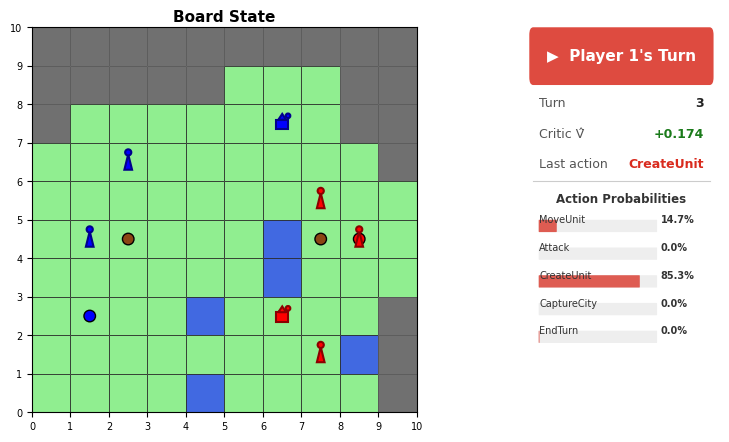

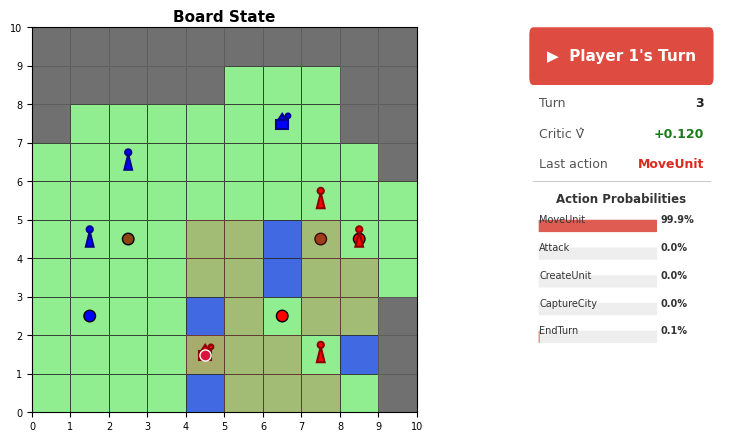

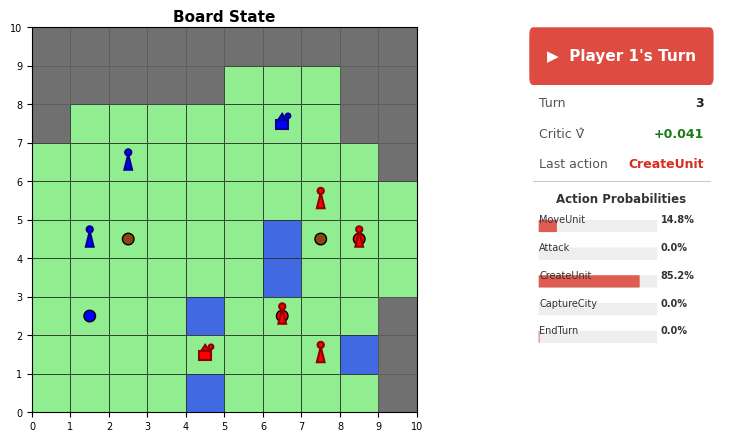

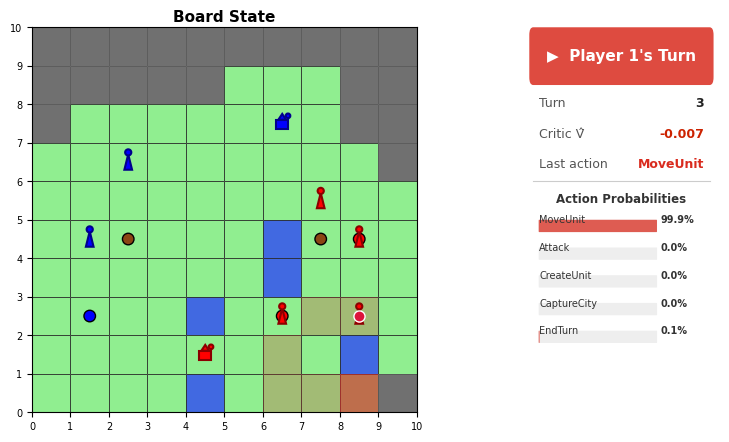

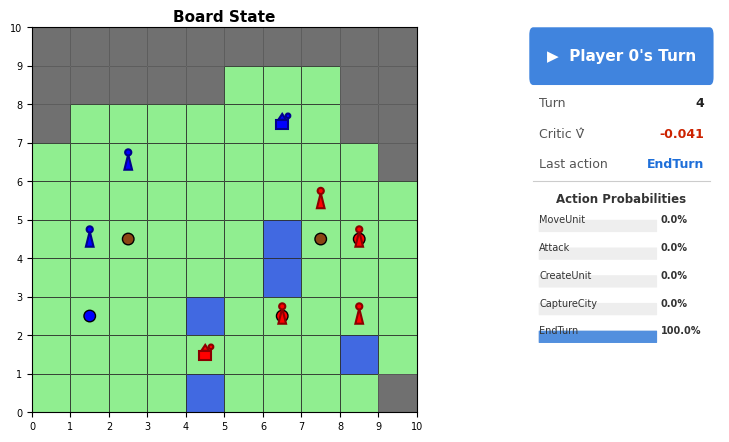

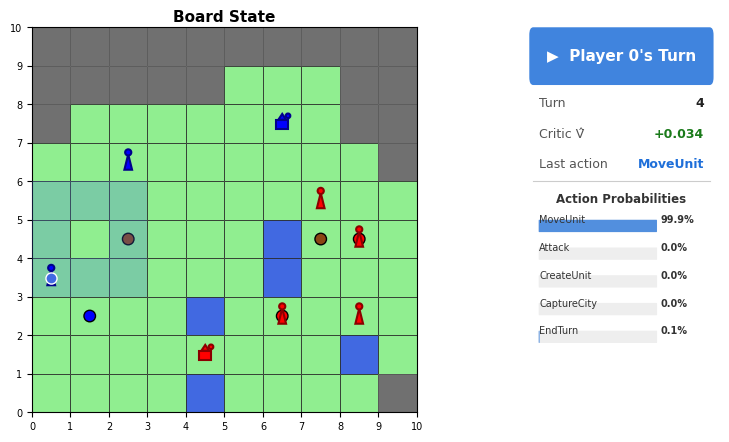

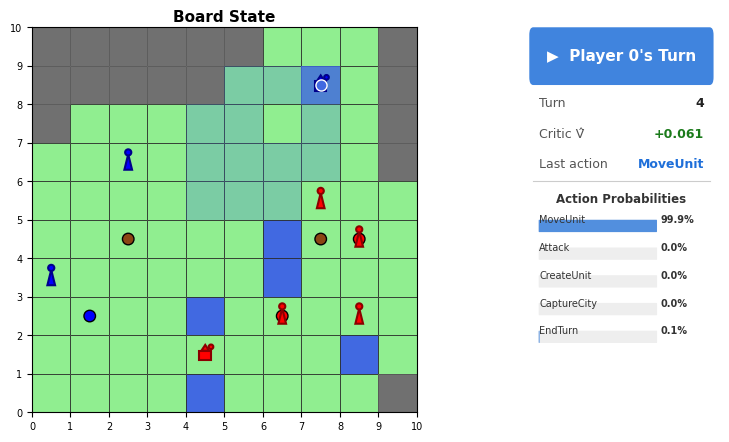

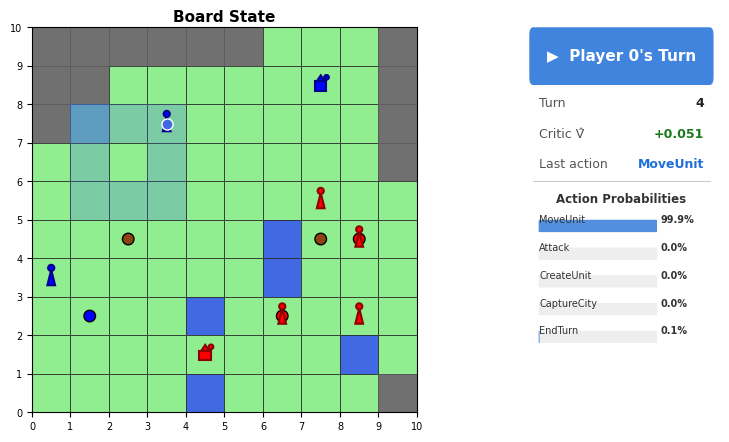

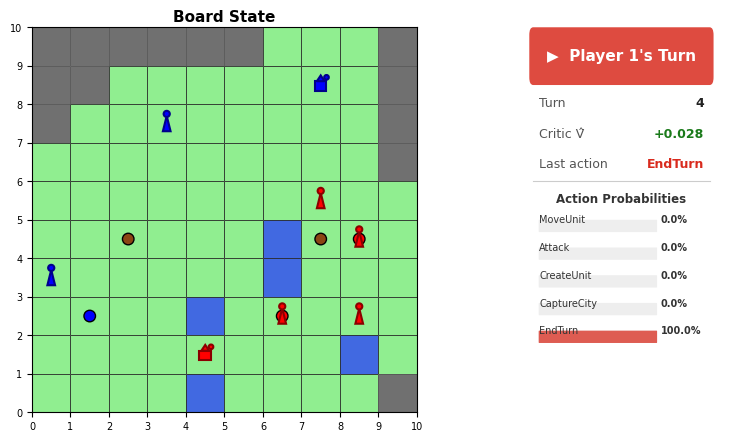

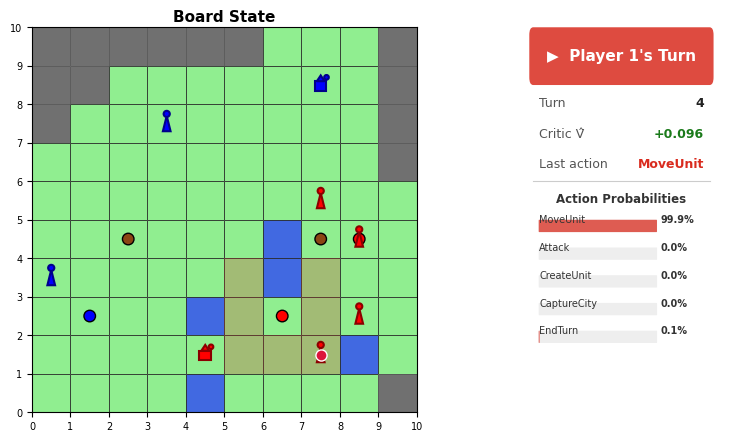

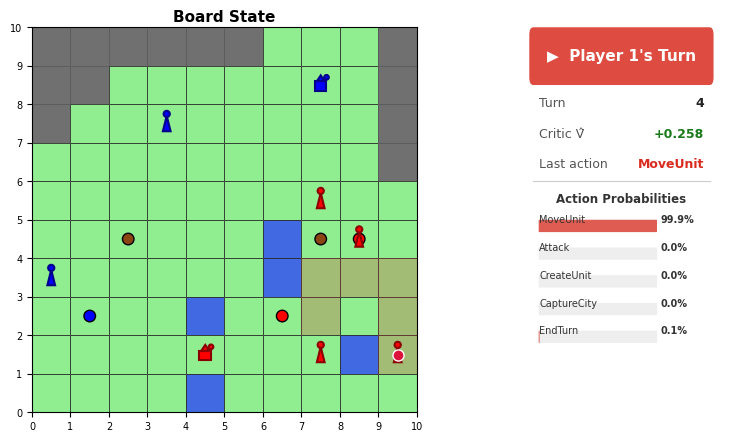

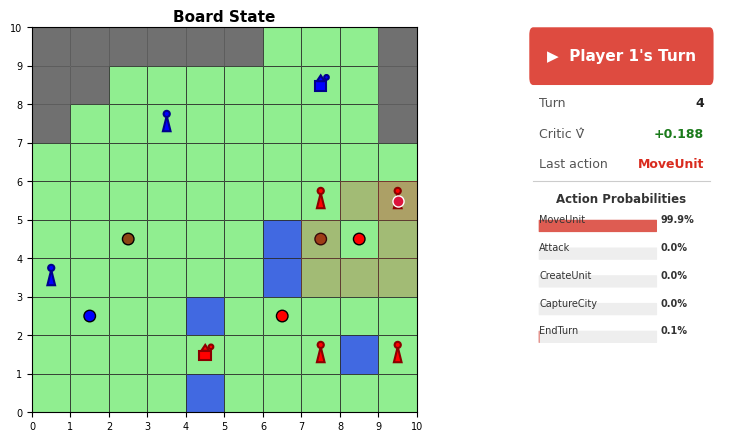

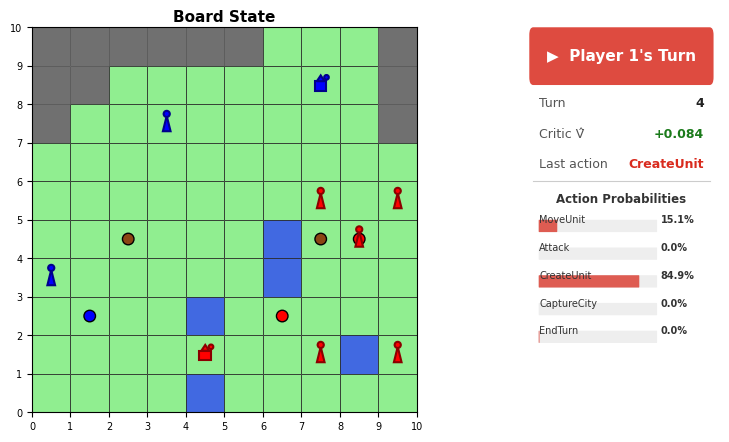

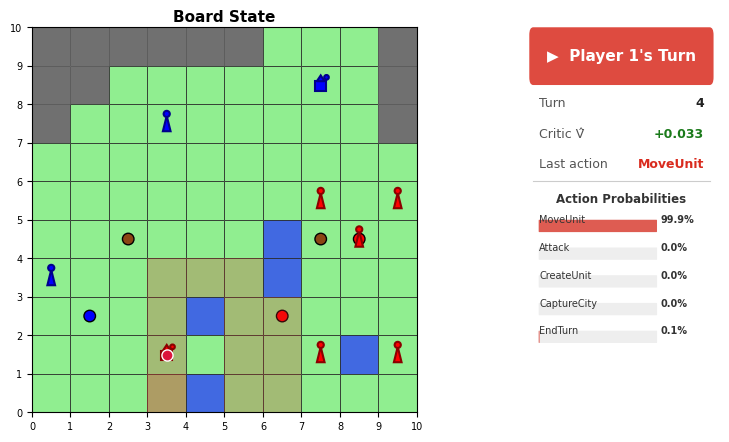

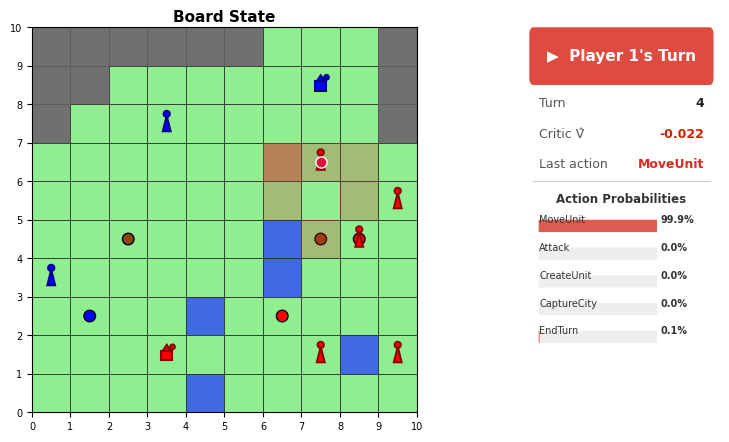

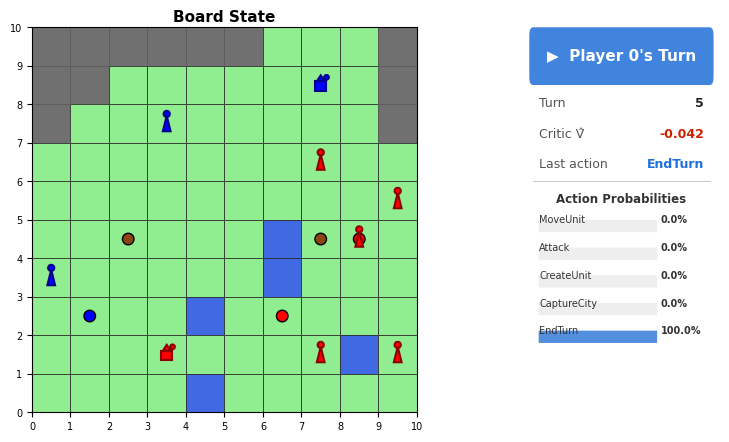

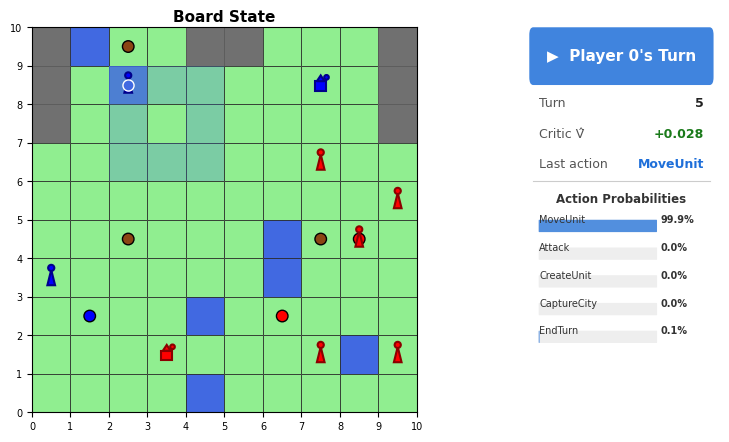

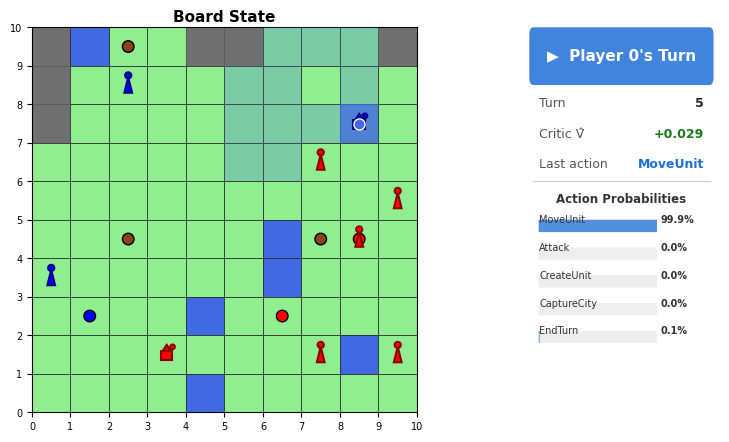

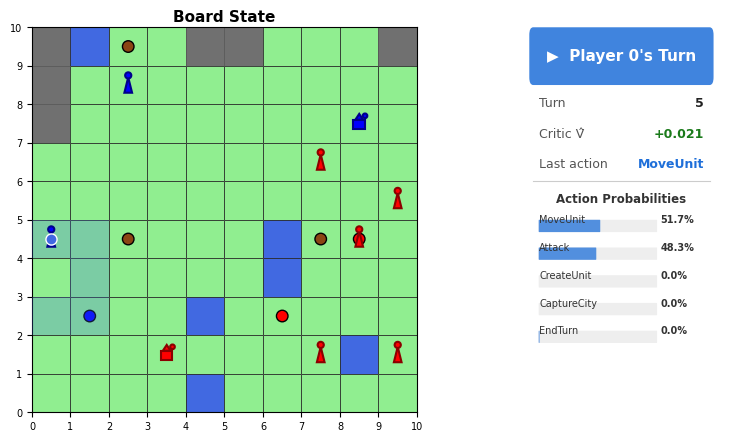

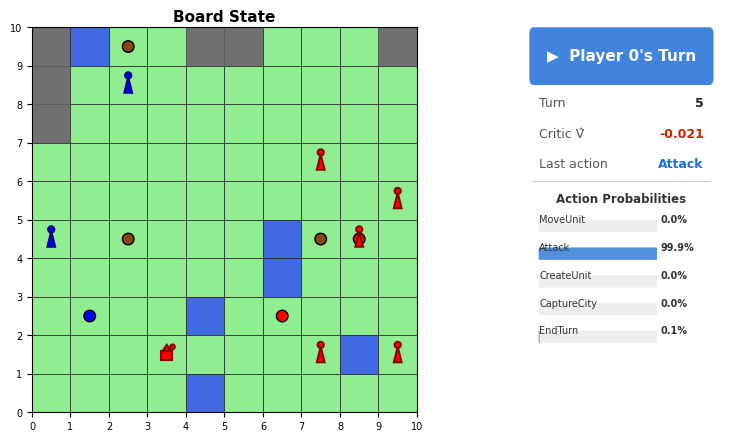

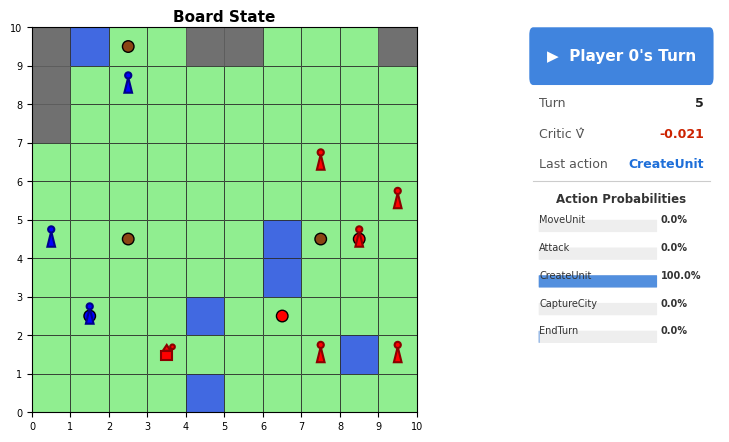

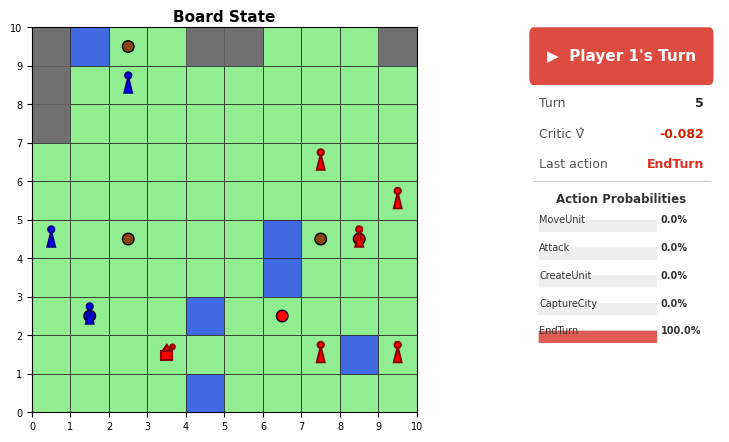

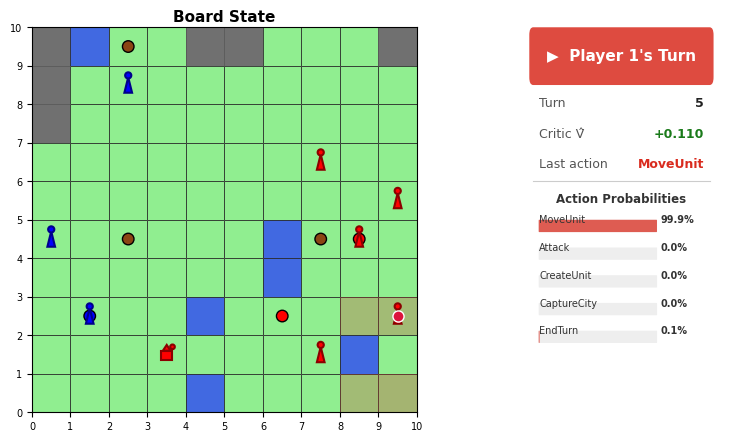

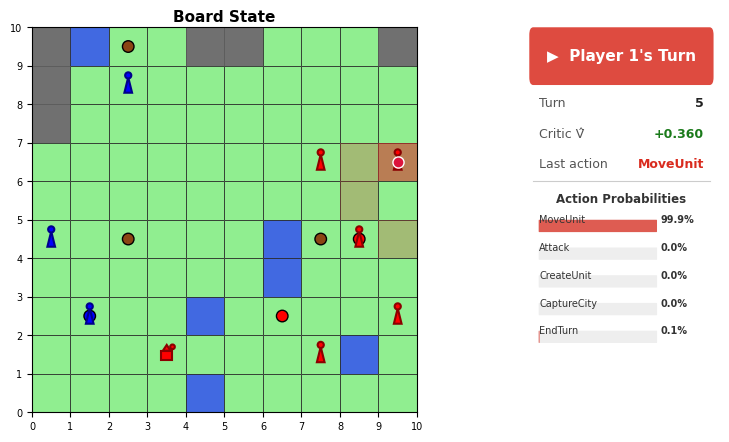

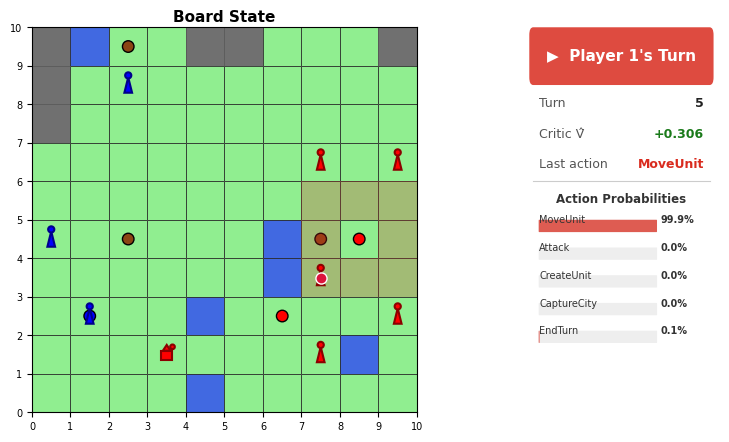

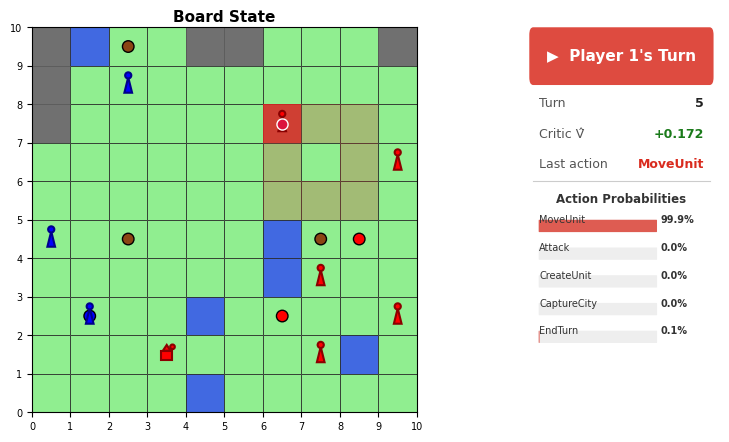

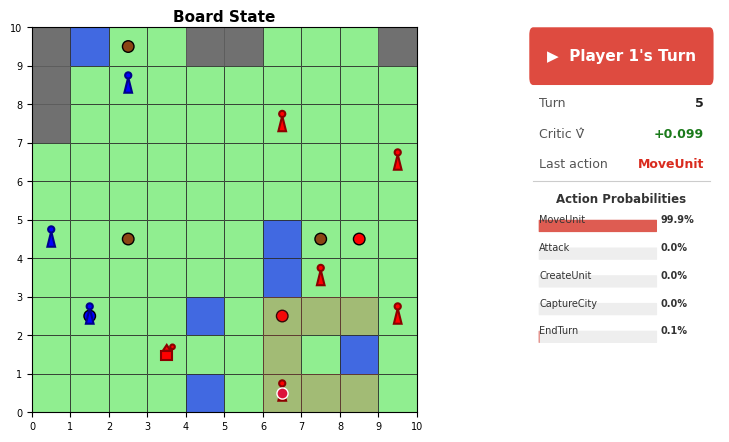

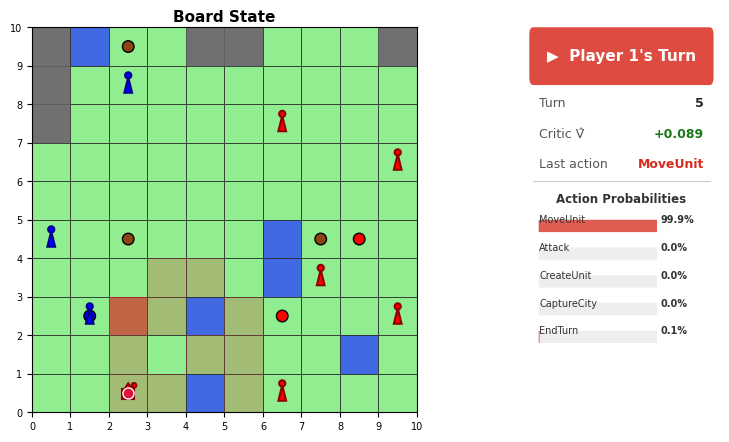

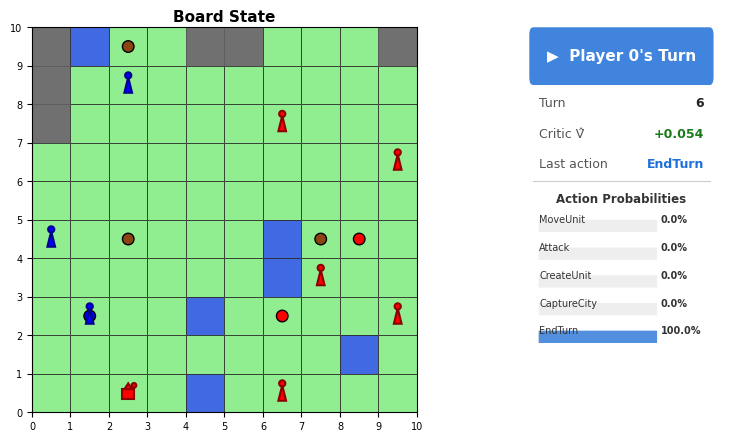

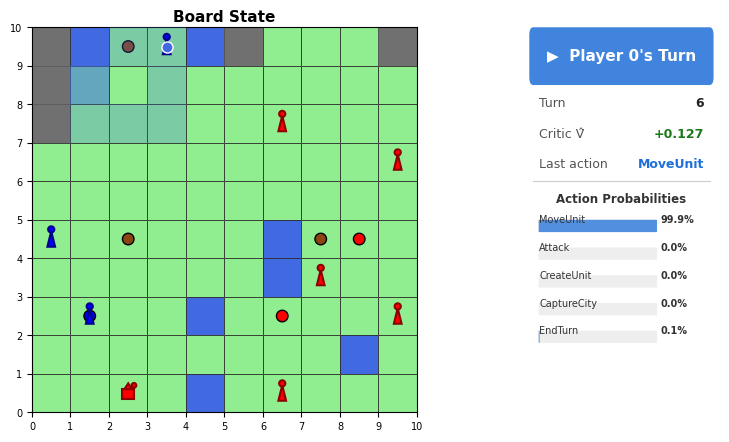

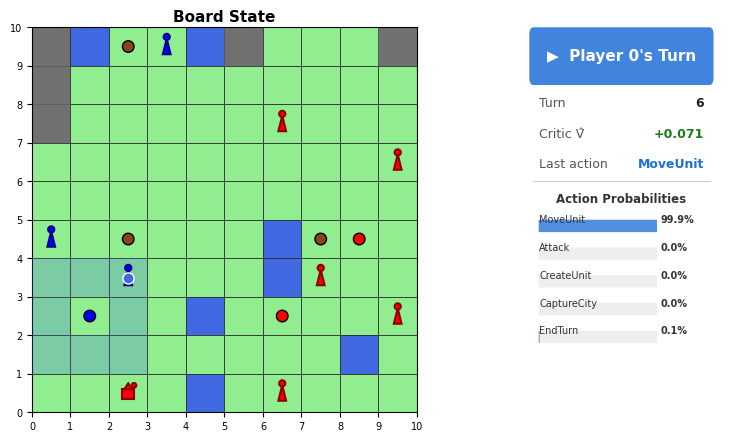

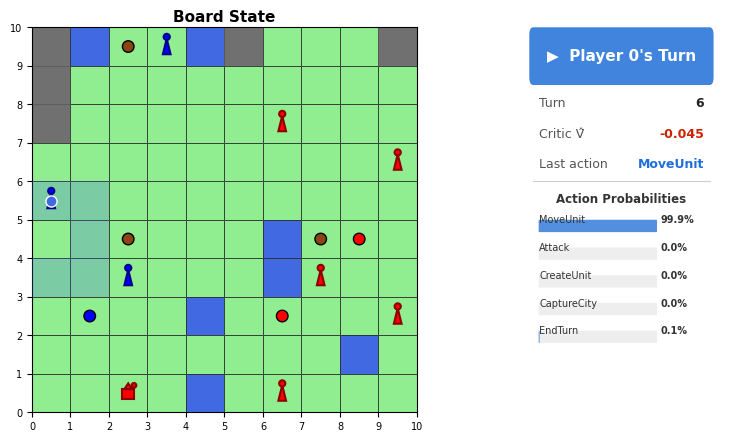

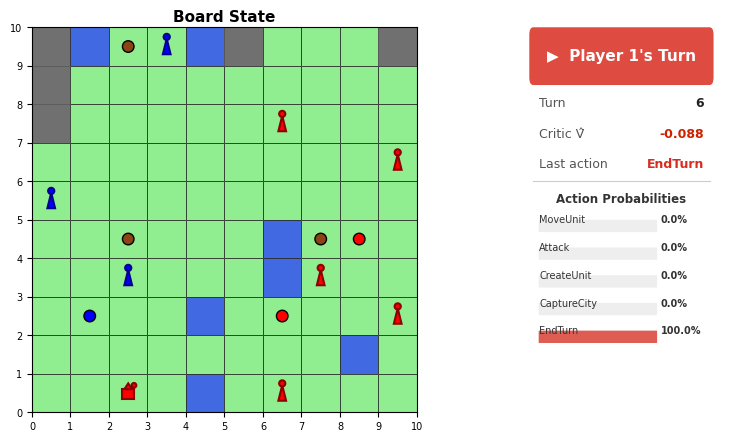

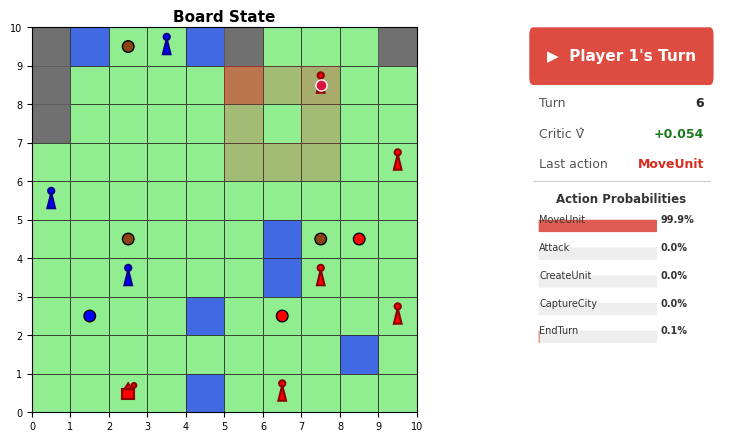

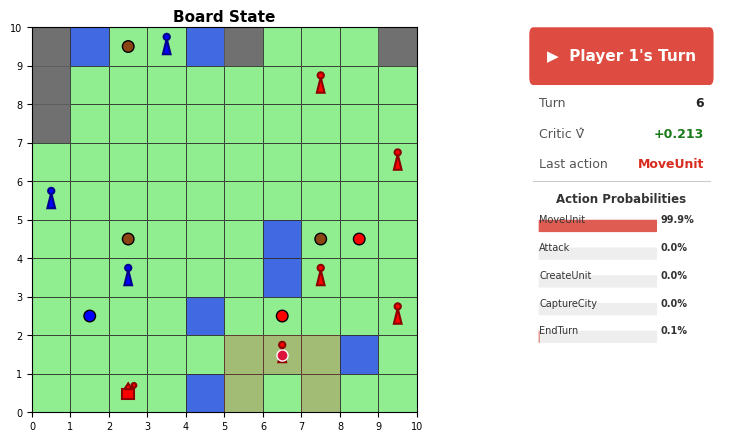

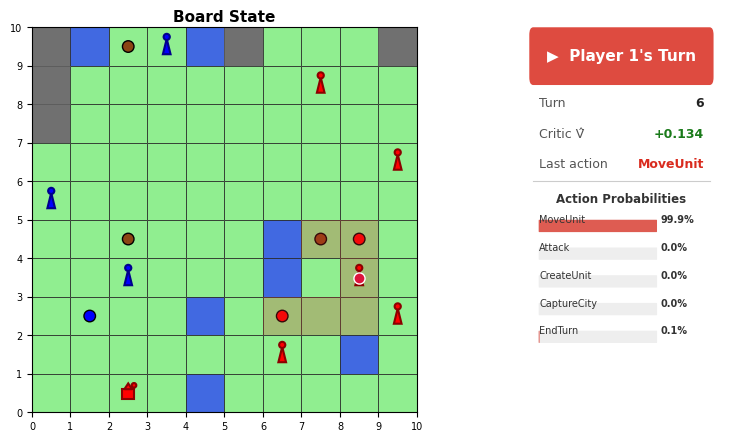

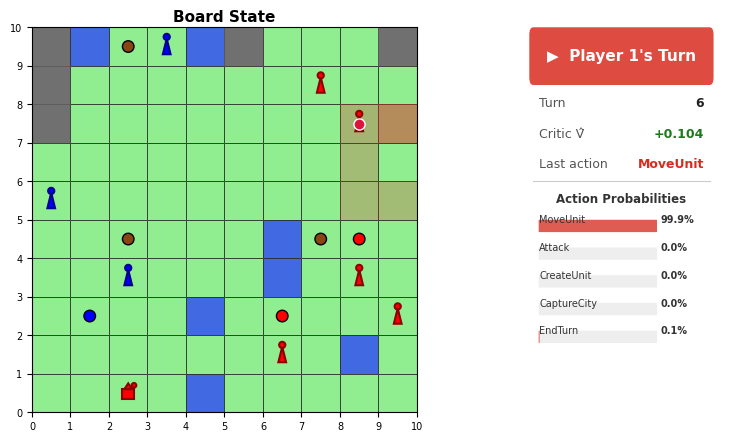

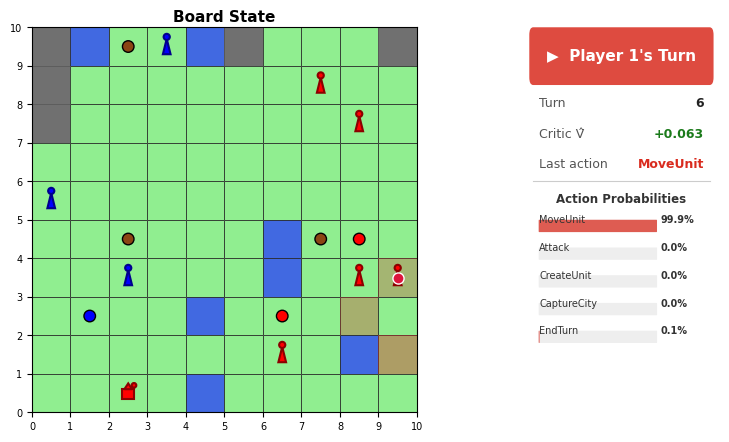

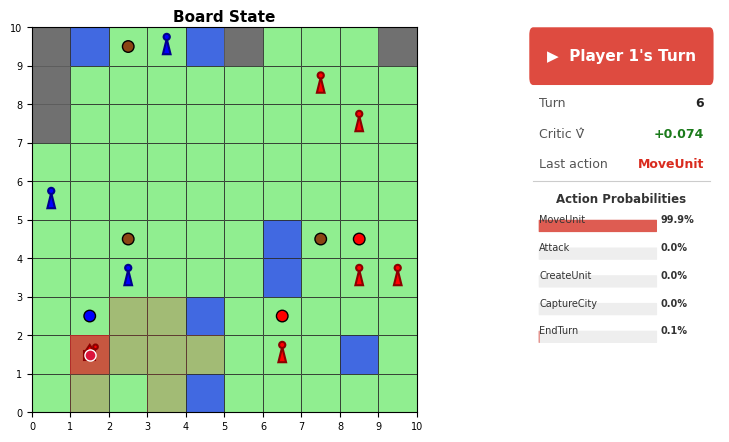

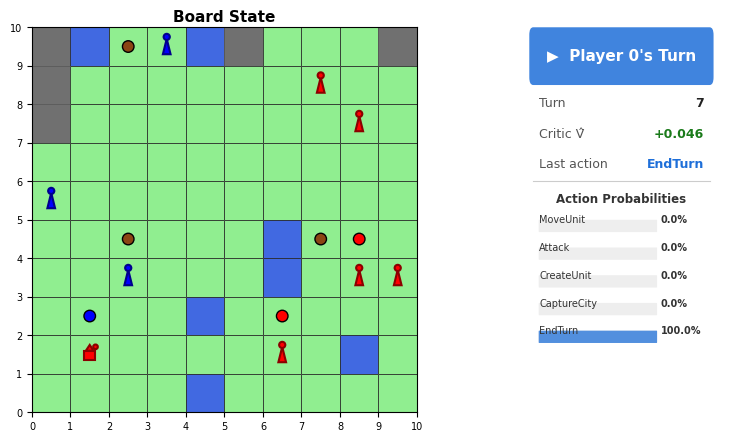

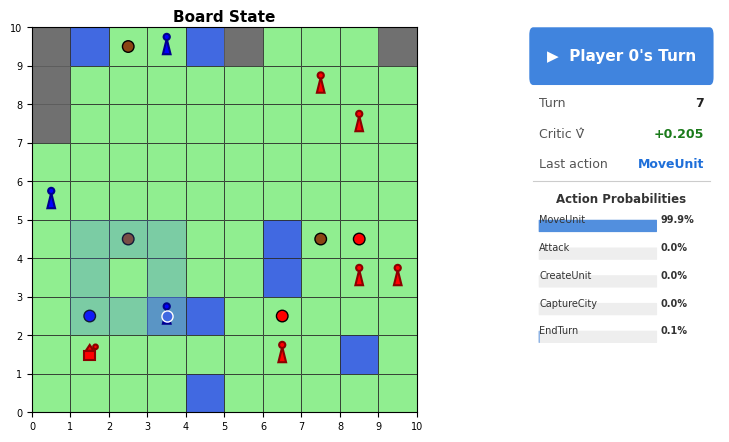

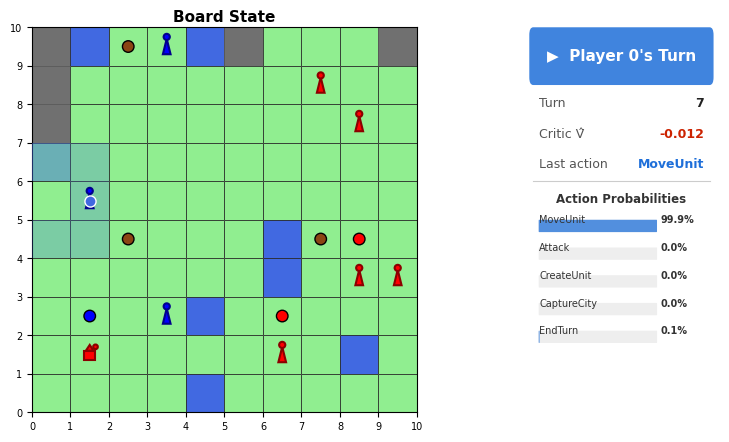

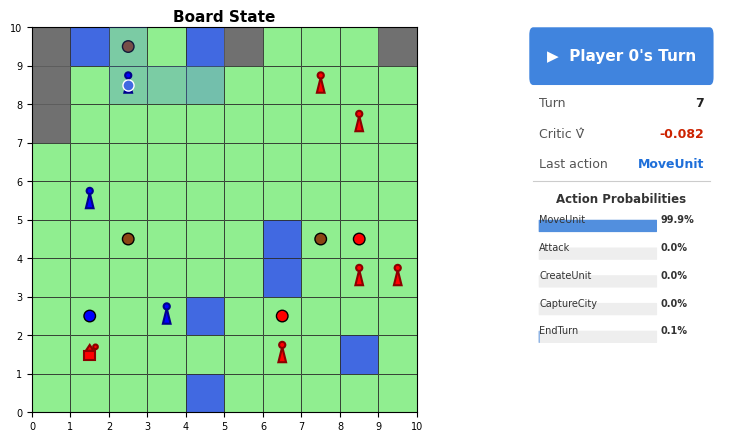

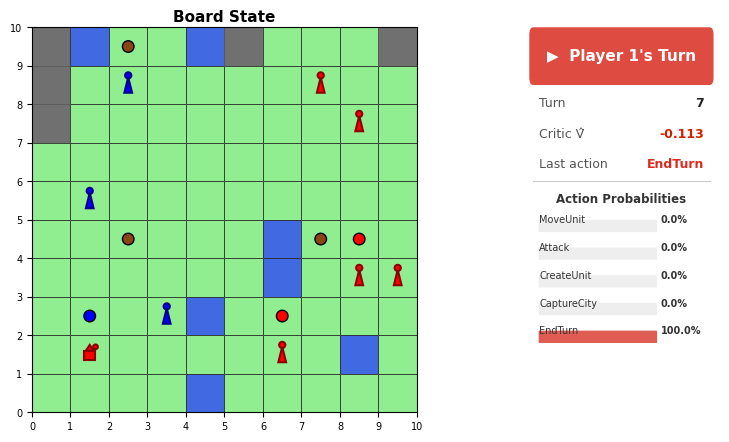

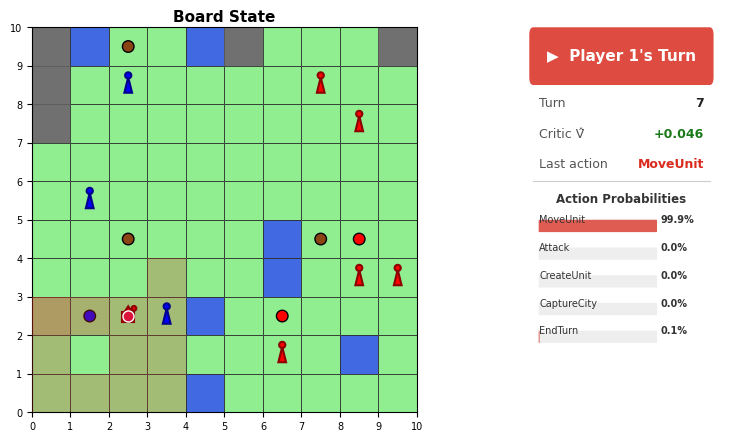

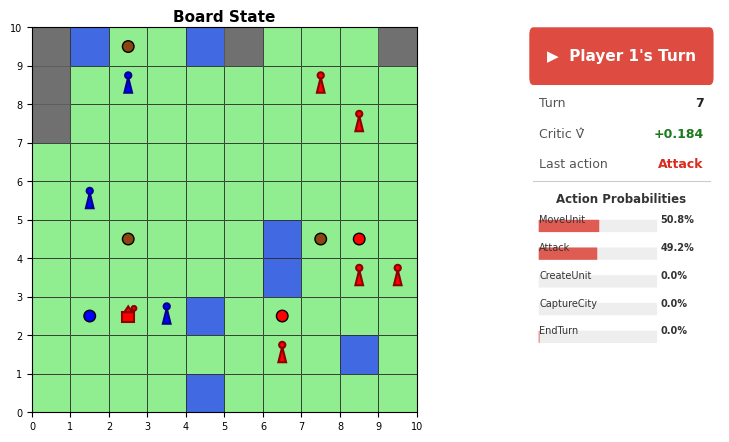

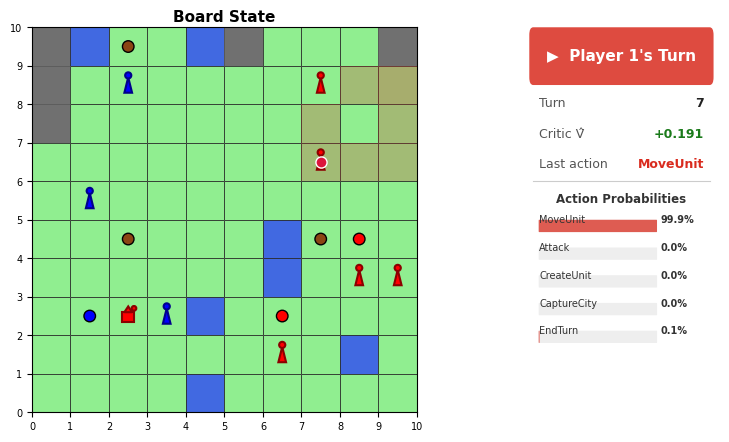

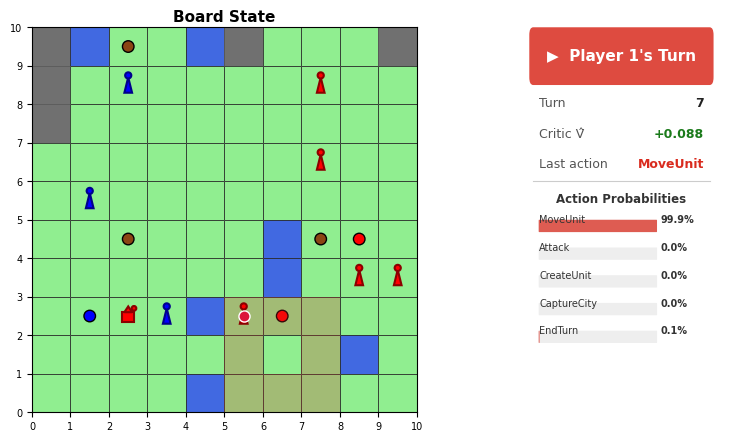

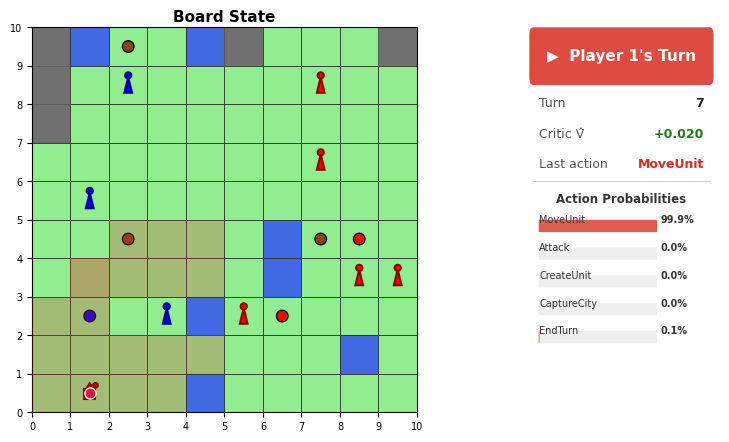

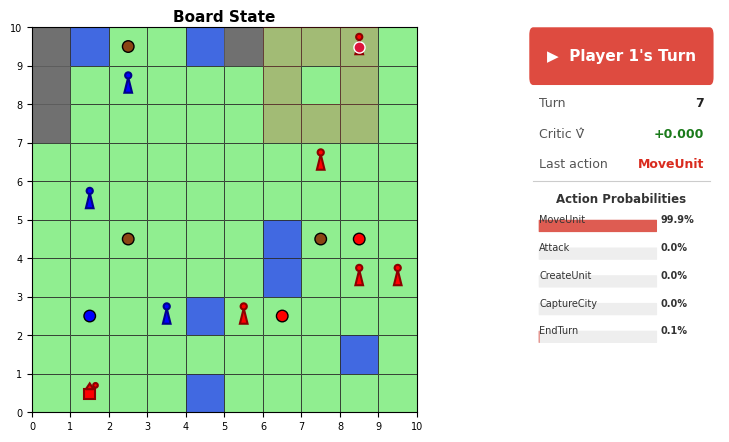

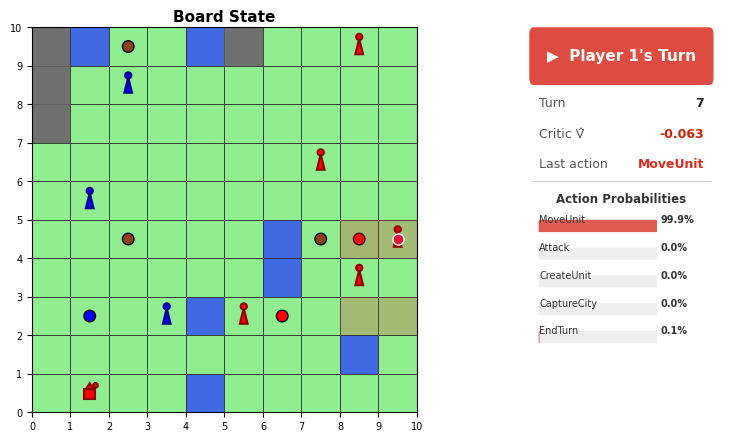

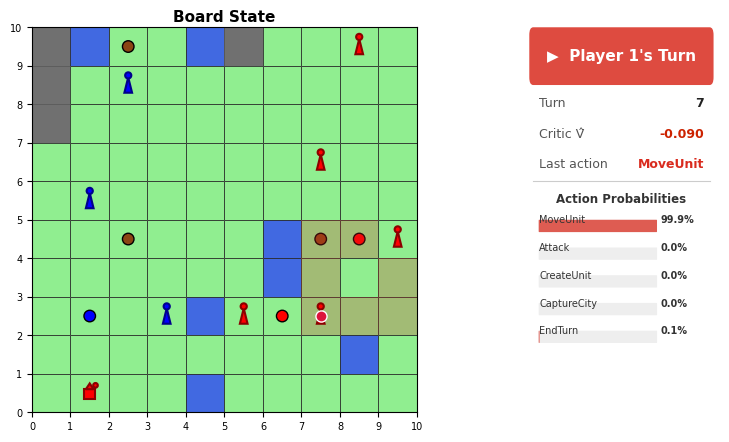

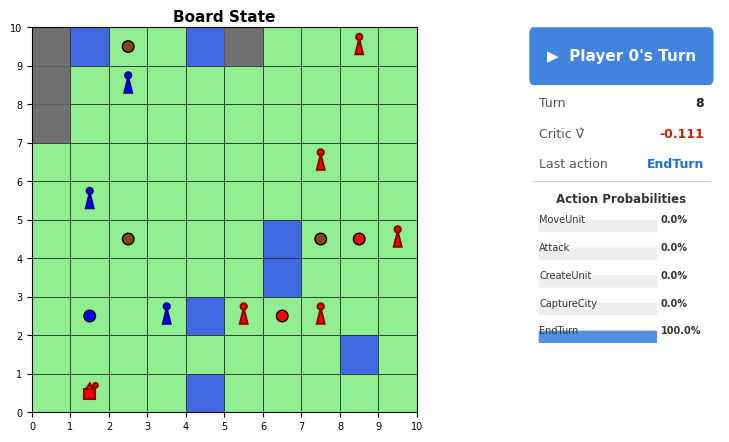

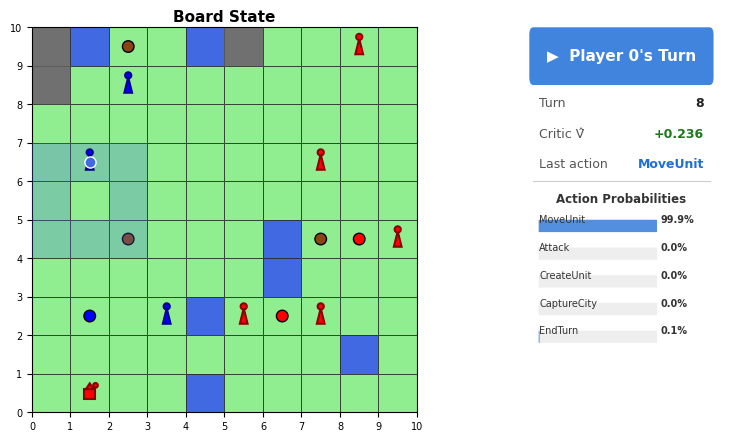

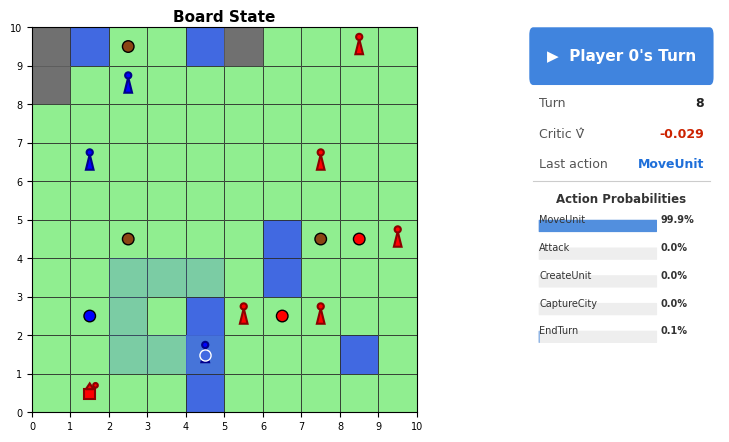

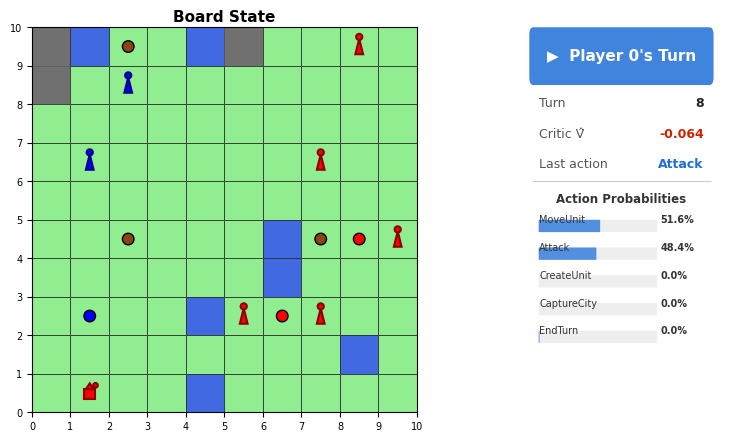

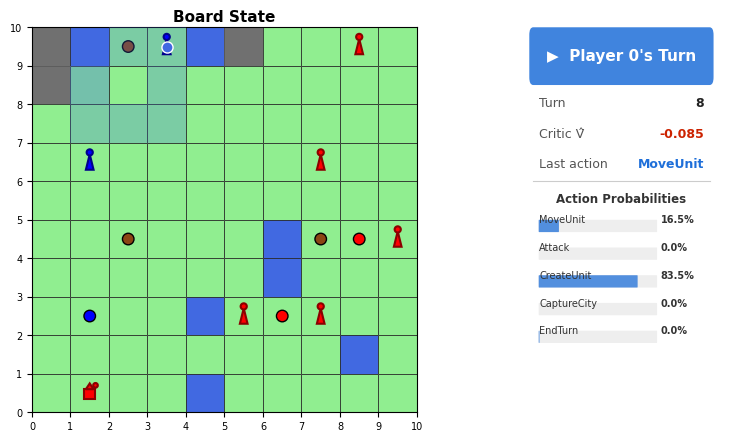

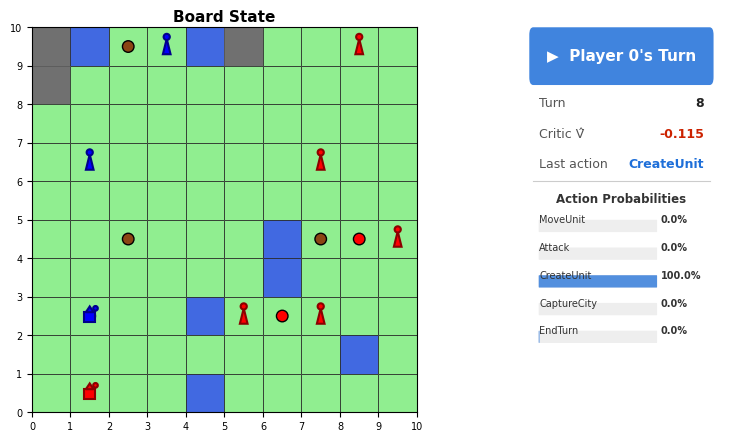

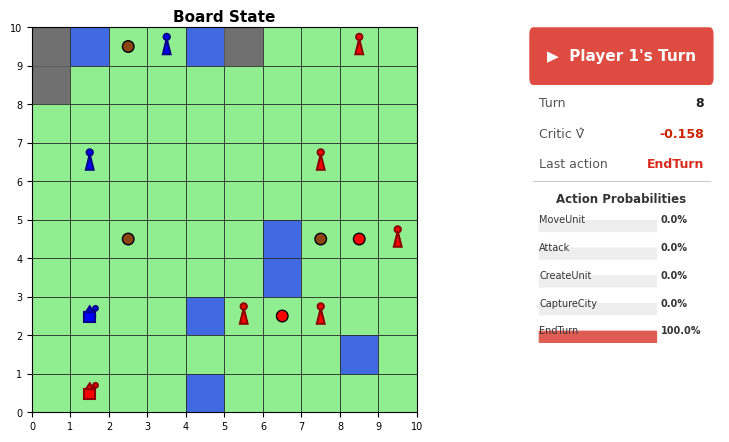

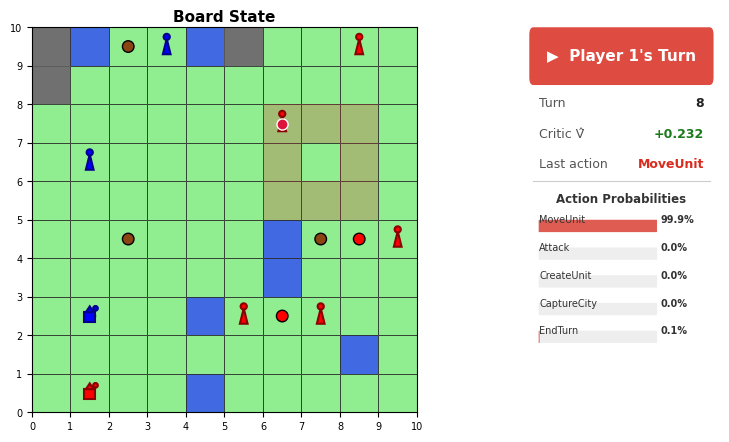

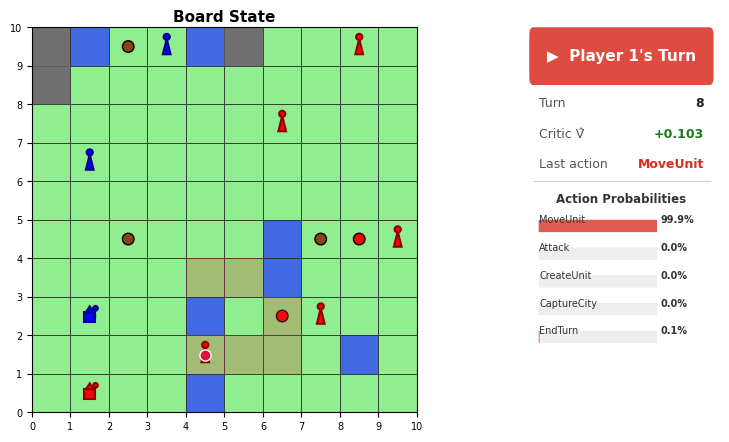

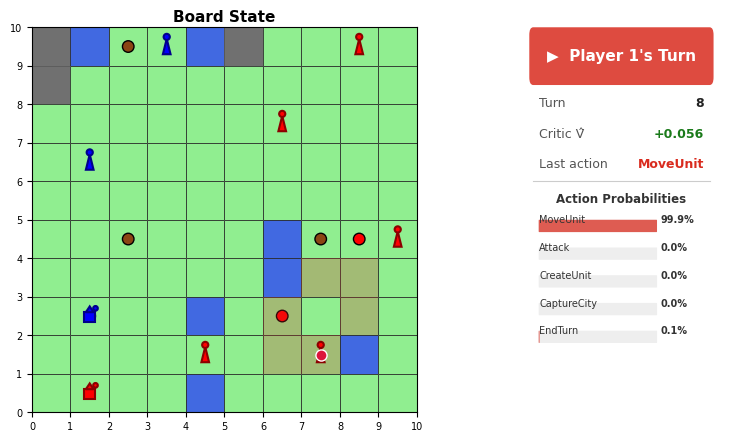

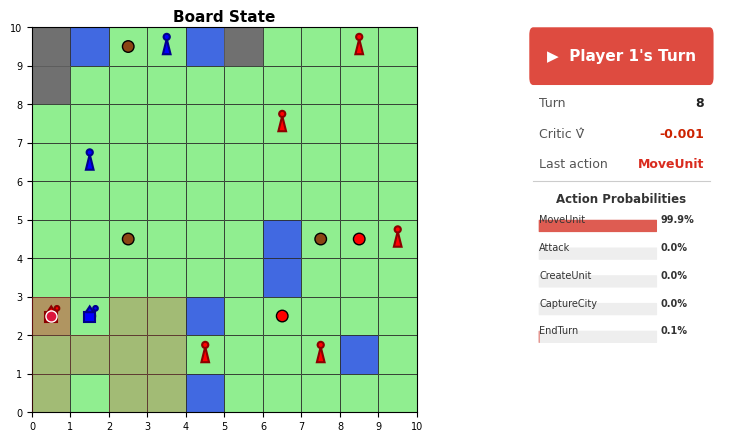

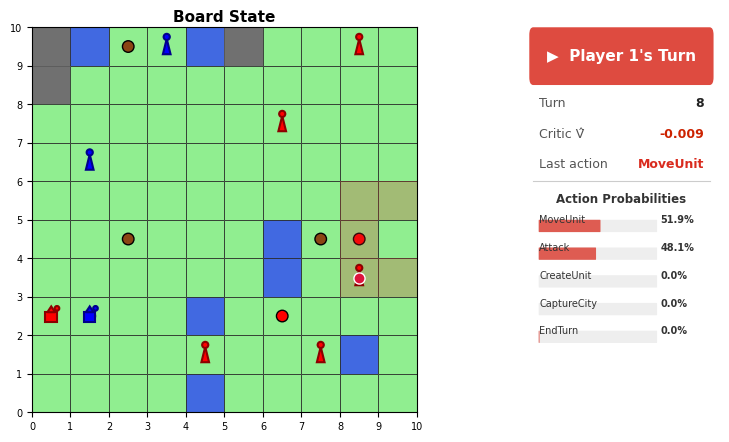

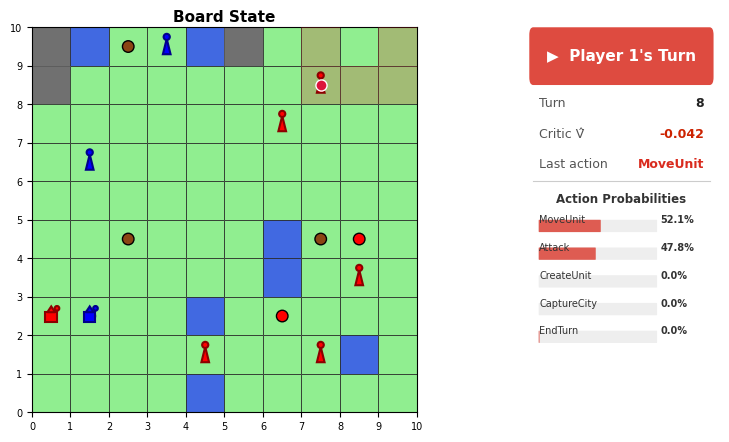

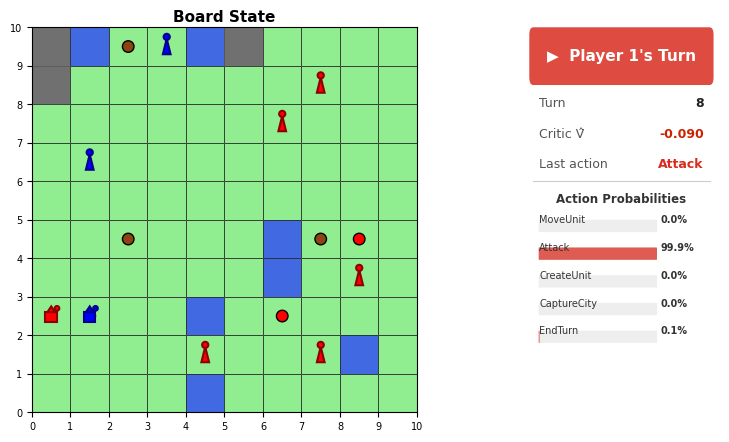

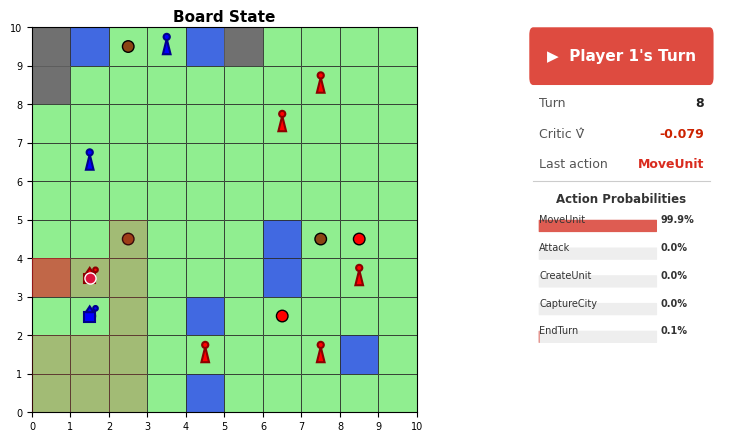


Game over — winner: Draw (turn limit)


In [15]:
env = EnvWrapper(board_config_dict, cfg.player_tribes,
                 max_turns_per_game=cfg.max_turns_per_game,
                 dense_reward=True)
obs  = env.reset()
done = False
step = 0

for i in range(100):
    mask             = env.get_action_mask()
    #print("-"*40,"Step {} mask".format(i),"-"*40,"\n",mask, "\n")
    
    with torch.no_grad():
        action, all_probs, all_trajs,_, _, value = policy(obs, mask)

    #print("value:", value)
    #print(calc_probs_global_action_head(policy, obs, mask))
    #for a, p in zip(all_trajs, all_probs):
    #    print(env._translate_action(a), p)
    obs, reward, done, info = env.step(action)

    
    #print(f"step {step:3d} | action: {info['log'].get('action_type')} | reward: {reward:.2f}")
    if i > 0:
        env.render_with_trajs(shared_fog=True, critic_value=value,
                              action=action,
                              joint_probs=all_probs, traj_actions=all_trajs)
    #for unit in env.game.players[env.game.player_go_id].units_under_control:
        #tile_id = unit.tile.id
        #print(unit)
        #print(env.game.players[env.game.player_go_id].partial_graph[tile_id])
    step += 1

    if done:
        print("We have a winner!")
        break

    
winner = env.winner
print(f"\nGame over — winner: {'Player ' + str(winner) if winner is not None else 'Draw (turn limit)'}")